# **PONTIFICIA UNIVERSIDAD JAVERIANA**
## **Procesamiento de alto volumen de datos**
**Fecha:** 19 de mayo del 2026

**Autor:** Grupo Sigma

**Tema:** Proyecto de Big Data

**Objetivo:** 
- Entender la importancia del uso de herramientas de Big Data en entornos empresariales, a fin de poder solucionar preguntas de negocio.
- Entender el paso a paso de un proyecto de procesamiento de datos para la generación de hallazgos de valor basado en la metodología CRISP-DM.
- Documentar la implementación de un cluster como infraestructura de procesamiento de grandes volúmenes de datos, a través de máquinas virtuales
- Realizar procesamiento de datos aplicado a un problema real.

**Versión:** 2.0

Para asegurar que el proyecto funcione correctamente con pandas, matplotlib, seaborn y findspark, ejecutar el siguiente comando desde la raíz del proyecto
```bash
pip install -r requirements.txt
```

In [1]:
### Importación de bibliotecas basicas 
import os # -> Para gestion de archivos y procesos
import sys # -> Para manejo de recursos del sistema
import pandas as pd # -> Para graficar y objetos dataframe
import numpy as np # -> Para algebra matricial
import matplotlib.pyplot as plt # -> Para formatos de graficas
import seaborn as sns # -> Para estadistica y graficar
import scipy.stats as stats # -> Para pruebas estadisticas

In [2]:
### Importacion de bibliotecas especializadas
import findspark
findspark.init('/Almacen/Spark')
from pyspark import SparkConf, SparkContext
from pyspark.sql import SparkSession
from pyspark.sql.functions import *
from pyspark.sql.types import IntegerType, StringType, DoubleType
import pyspark.sql.functions as F
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler
from pyspark.ml.stat import Correlation
from pyspark.ml import Pipeline
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.linalg import Vectors, VectorUDT
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator
from pyspark.ml.tuning import ParamGridBuilder
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score, classification_report, roc_curve

2026-05-24 13:46:31.056248: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-05-24 13:46:31.156734: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-05-24 13:46:33.266822: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [3]:
configura = SparkConf()
configura.set('spark.scheduler.mode', 'FAIR')
configura.set('spark.scheduler.allocation','/Almacen/Spark/conf/fairscheduler.xml')
configura.setMaster('spark://10.43.97.166:7077')
configura.setAppName('SigmaSPARK')

sparkSigma = SparkSession.builder.config(conf=configura).getOrCreate()
sparkSigma

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/05/24 13:46:37 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


### Actividades realizadas

- Lectura de data
- Descripción de los datos
- Exploración de los datos
- Reporte de calidad
- Planteamiento de preguntas investigativas
- Limpieza, filtros y transformaciones
- Respuesta a preguntas de negocio
- Selección de técnicas de aprendizaje de máquina
- Preparación de datos para modelado
- Modelado supervisado (Random Forest — MLlib/Spark)
- Modelado no supervisado (K-Means — MLlib/Spark)
- Evaluación con métricas y comparación de parámetros
- Red neuronal profunda (TensorFlow/Keras)


## **Lectura de data**

In [4]:
## Se crea el dataframe para acceder al sistema de fichero csv como un objeto dataframe pyspark
## El acceso se hara desde el sistema de ficheros Hadoop HDFS
dfPy00 = sparkSigma.read.format("csv").option("header","true").load("../data/Beneficiarios_Estrategia_UNIDOS_20260407.csv")
dfPy00.show(5)

26/05/24 13:46:48 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


+-------------+-------------+---------+----+--------------------------+--------------------------+-----------------------+-----------------------+-------------+------------------+---------------+------------+---------------+-------+-----+------+-----------------+-------------+------------------+---------+---------+---------+------------+---------+---------+---------+---------+---------+------------+---------+---------+---------+---------+------------+------------+---------+------------+------------+------------+---------+---------+------------+---------+------------+------------+----+----+----+----+----+----+----+----+------------------+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+
|CodigoFamilia|TipoDocumento|RangoEdad|Pais|CodigoDepartamentoAtencion|NombreDepartamentoAtencion|CodigoMunicipioAtencion|NombreMunicipioAtencion|PuntajeSISBEN|BeneficiarioSISBEN|CondicionSexual|Discapacidad|    EstadoCivil|Estrato|Etnia|Genero|       Parente

In [5]:
## Municipios del proyecto: cubren diversidad de contextos geográficos,
## económicos y sociales para hacer comparaciones territoriales significativas
MUNICIPIOS_PROYECTO = [
    "BOGOTA D.C.",
    "QUIBDO",
    "URIBIA",
    "MEDELLIN",
    "LETICIA",
    "SAN ANDRES",
    "BUENAVENTURA",
    "MITU",
    "TUNJA",
    "BOJAYA"
]

print(f"Municipios de análisis: {len(MUNICIPIOS_PROYECTO)}")
for m in MUNICIPIOS_PROYECTO:
    print(f"  - {m}")

Municipios de análisis: 10
  - BOGOTA D.C.
  - QUIBDO
  - URIBIA
  - MEDELLIN
  - LETICIA
  - SAN ANDRES
  - BUENAVENTURA
  - MITU
  - TUNJA
  - BOJAYA


Los 10 municipios seleccionados abarcan realidades muy distintas del país: desde la capital y ciudades con inversión en infraestructura digital (Bogotá, Medellín, Tunja) hasta municipios con alta concentración de pobreza extrema y baja conectividad (Quibdó, Bojayá, Uribia, Mitú). Esta diversidad permite contrastar el impacto diferencial de la pobreza sobre los resultados educativos.

## **Descripción de los datos**

**Se hace la introduccion sobre los datos de "Beneficiarios de la estrategia Unidos" de beneficiarios almacenados sobre datos estructurados "csv"**

### **Análisis de la Fuente de Datos**

Tras la carga inicial del conjunto de datos mediante PySpark, se procede a realizar una interpretación técnica y de negocio de la información disponible. Este dataset permite caracterizar la población en situación de pobreza extrema en Colombia.

#### Resumen de Metadatos

- Nombre del Dataset: Beneficiarios Estrategia UNIDOS.
- Entidad Origen: Departamento Administrativo para la Prosperidad Social (DPS).
- Volumen de Datos: Aproximadamente 1.51 Millones de filas y 73 columnas.
- Granularidad: Cada registro representa a un individuo (beneficiario) perteneciente a un hogar focalizado.

#### Estructura de las Variables

El dataset se organiza en cuatro dimensiones principales:
1. Identificación y Ubicación: Incluye códigos de familia, tipos de documento y ubicación geográfica (Departamento/Municipio) mediante códigos DIVIPOLA.
2. Caracterización Sociodemográfica: Variables como RangoEdad, Genero, Etnia, EstadoCivil y Discapacidad. Es notable la inclusión de CondicionSexual para análisis de diversidad.
3. Seguimiento de Logros (Estrategia UNIDOS): Un bloque de 26 variables (Logro1 a Logro26) que miden el estado de superación de la pobreza (e.g., Alfabetismo, Acceso a Agua, Seguridad Alimentaria).
4. Dimensiones de Salud y Vivienda (Encuesta PE/HE): Variables técnicas que detallan condiciones físicas del hogar (paredes, pisos, hacinamiento) y condiciones de salud específicas.



### **Analisis premilinar**

Al observar las primeras 5 filas del objeto dfPy00, se identifican los siguientes puntos para la fase de Preparación de Datos:
- Valores Nulos y Desconocidos: Se detecta la presencia de etiquetas como ND (No Definido), Sin Información y NULL. Será necesario estandarizar estos valores para no sesgar las estadísticas.
- Tipado de Datos: Aunque columnas como PuntajeSISBEN y Estrato son conceptualmente numéricas, la carga inicial desde CSV a menudo las interpreta como String. Se requiere un casting explícito a IntegerType o DoubleType.
- Codificación de Logros: Las columnas de logros utilizan categorías textuales (ALCANZADO, POR ALCANZAR, NO APLICA). Para modelos analíticos, se sugiere una transformación a variables dummy o escala ordinal.
- Consistencia Geográfica: Las columnas CodigoDepartamentoAtencion y CodigoMunicipioAtencion deben tratarse como cadenas (strings) para preservar los ceros a la izquierda (por ejemplo, 05 para Antioquia).

### **Diagnóstico y tratamiento de datos sobre Pyspark**

- **1** Cambio de nombre de columnas
- **2** Tipos y coherencia de datos
- **3** Identificación y tratamiento de nulos 
- **4** Estadísticas generales
- **5** Categorías y cambio sobre el tipo de datos de las categorías

### 1 - Cambio de nombre de columnas

In [6]:
### Se despliega las columnas
dfPy00.columns

['CodigoFamilia',
 'TipoDocumento',
 'RangoEdad',
 'Pais',
 'CodigoDepartamentoAtencion',
 'NombreDepartamentoAtencion',
 'CodigoMunicipioAtencion',
 'NombreMunicipioAtencion',
 'PuntajeSISBEN',
 'BeneficiarioSISBEN',
 'CondicionSexual',
 'Discapacidad',
 'EstadoCivil',
 'Estrato',
 'Etnia',
 'Genero',
 'Parentesco',
 'TipoPoblacion',
 'EstadoBeneficiario',
 'Logro1',
 'Logro2',
 'Logro3',
 'Logro4',
 'Logro5',
 'Logro6',
 'Logro7',
 'Logro8',
 'Logro9',
 'Logro10',
 'Logro11',
 'Logro12',
 'Logro13',
 'Logro14',
 'Logro15',
 'Logro16',
 'Logro17',
 'Logro18',
 'Logro19',
 'Logro20',
 'Logro21',
 'Logro22',
 'Logro23',
 'Logro24',
 'Logro25',
 'Logro26',
 'PE34',
 'PE35',
 'PE36',
 'PE37',
 'PE38',
 'PE39',
 'PE40',
 'PE41',
 'PE42',
 'PE43',
 'PE44',
 'PE45',
 'PE46',
 'PE48',
 'PE50',
 'PE51',
 'HE11',
 'HE12',
 'HE13',
 'HE14',
 'HE15',
 'HE16',
 'HE17',
 'HE18',
 'HE20',
 'HE21',
 'HE22',
 'HE23']

In [7]:
## Se listan los nombres de las columnas actuales y los nombres por los que deseo cambiar del dataframe
NombresOriginales = [
    'CodigoFamilia', 'TipoDocumento', 'RangoEdad', 'Pais',
    'CodigoDepartamentoAtencion', 'NombreDepartamentoAtencion',
    'CodigoMunicipioAtencion', 'NombreMunicipioAtencion',
    'PuntajeSISBEN', 'BeneficiarioSISBEN', 'CondicionSexual',
    'Discapacidad', 'EstadoCivil', 'Estrato', 'Etnia',
    'Genero', 'Parentesco', 'TipoPoblacion', 'EstadoBeneficiario'
]

NombresNuevos = [
    'ID_FAMILIA', 'TIPO_DOC', 'RANGO_EDAD', 'PAIS',
    'COD_DEP', 'NOM_DEP', 'COD_MUN', 'NOM_MUN',
    'PUNTAJE_SISBEN', 'TIENE_SISBEN', 'ORIENT_SEXUAL',
    'DISCAPACIDAD', 'ESTADO_CIVIL', 'ESTRATO', 'ETNIA',
    'GENERO', 'PARENTESCO', 'TIPO_POBLACION', 'ESTADO_BENEF'
]

dfPy01 = dfPy00
for antes, nuevo in zip(NombresOriginales, NombresNuevos):
    dfPy01 = dfPy01.withColumnRenamed(antes, nuevo)

dfPy01.columns

['ID_FAMILIA',
 'TIPO_DOC',
 'RANGO_EDAD',
 'PAIS',
 'COD_DEP',
 'NOM_DEP',
 'COD_MUN',
 'NOM_MUN',
 'PUNTAJE_SISBEN',
 'TIENE_SISBEN',
 'ORIENT_SEXUAL',
 'DISCAPACIDAD',
 'ESTADO_CIVIL',
 'ESTRATO',
 'ETNIA',
 'GENERO',
 'PARENTESCO',
 'TIPO_POBLACION',
 'ESTADO_BENEF',
 'Logro1',
 'Logro2',
 'Logro3',
 'Logro4',
 'Logro5',
 'Logro6',
 'Logro7',
 'Logro8',
 'Logro9',
 'Logro10',
 'Logro11',
 'Logro12',
 'Logro13',
 'Logro14',
 'Logro15',
 'Logro16',
 'Logro17',
 'Logro18',
 'Logro19',
 'Logro20',
 'Logro21',
 'Logro22',
 'Logro23',
 'Logro24',
 'Logro25',
 'Logro26',
 'PE34',
 'PE35',
 'PE36',
 'PE37',
 'PE38',
 'PE39',
 'PE40',
 'PE41',
 'PE42',
 'PE43',
 'PE44',
 'PE45',
 'PE46',
 'PE48',
 'PE50',
 'PE51',
 'HE11',
 'HE12',
 'HE13',
 'HE14',
 'HE15',
 'HE16',
 'HE17',
 'HE18',
 'HE20',
 'HE21',
 'HE22',
 'HE23']

In [8]:
dfPy01.show(5)

[Stage 2:>                                                          (0 + 1) / 1]

+-----------+--------+----------+----+-------+---------+-------+-------+--------------+------------+-------------+------------+---------------+-------+-----+------+-----------------+--------------+------------+---------+---------+---------+------------+---------+---------+---------+---------+---------+------------+---------+---------+---------+---------+------------+------------+---------+------------+------------+------------+---------+---------+------------+---------+------------+------------+----+----+----+----+----+----+----+----+------------------+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+
| ID_FAMILIA|TIPO_DOC|RANGO_EDAD|PAIS|COD_DEP|  NOM_DEP|COD_MUN|NOM_MUN|PUNTAJE_SISBEN|TIENE_SISBEN|ORIENT_SEXUAL|DISCAPACIDAD|   ESTADO_CIVIL|ESTRATO|ETNIA|GENERO|       PARENTESCO|TIPO_POBLACION|ESTADO_BENEF|   Logro1|   Logro2|   Logro3|      Logro4|   Logro5|   Logro6|   Logro7|   Logro8|   Logro9|     Logro10|  Logro11|  Logro12|  Logro13

### 2 - Tipos y coherencia de datos

In [9]:
## Se despliegan los tipos de datos y estructura del esquema
dfPy01.printSchema()

root
 |-- ID_FAMILIA: string (nullable = true)
 |-- TIPO_DOC: string (nullable = true)
 |-- RANGO_EDAD: string (nullable = true)
 |-- PAIS: string (nullable = true)
 |-- COD_DEP: string (nullable = true)
 |-- NOM_DEP: string (nullable = true)
 |-- COD_MUN: string (nullable = true)
 |-- NOM_MUN: string (nullable = true)
 |-- PUNTAJE_SISBEN: string (nullable = true)
 |-- TIENE_SISBEN: string (nullable = true)
 |-- ORIENT_SEXUAL: string (nullable = true)
 |-- DISCAPACIDAD: string (nullable = true)
 |-- ESTADO_CIVIL: string (nullable = true)
 |-- ESTRATO: string (nullable = true)
 |-- ETNIA: string (nullable = true)
 |-- GENERO: string (nullable = true)
 |-- PARENTESCO: string (nullable = true)
 |-- TIPO_POBLACION: string (nullable = true)
 |-- ESTADO_BENEF: string (nullable = true)
 |-- Logro1: string (nullable = true)
 |-- Logro2: string (nullable = true)
 |-- Logro3: string (nullable = true)
 |-- Logro4: string (nullable = true)
 |-- Logro5: string (nullable = true)
 |-- Logro6: string 

In [10]:
import pyspark.sql.functions as F

# Inicializamos el dataframe de transformación
dfPy02 = dfPy01

# 1. Tratamiento de Variables Numéricas (Casting)
columnas_a_entero = ['ESTRATO', 'PUNTAJE_SISBEN', 'HE17', 'HE18']
for col_name in columnas_a_entero:
    dfPy02 = dfPy02.withColumn(col_name, F.col(col_name).cast("int"))

# 2. Tratamiento de Logros (Mapeo a Enteros 1, 0, -1)
logros_cols = [c for c in dfPy02.columns if c.startswith('Logro')]

for c in logros_cols:
    dfPy02 = dfPy02.withColumn(c, 
        F.when(F.col(c) == "ALCANZADO", 1)
        .when(F.col(c) == "POR ALCANZAR", 0)
        .when(F.col(c) == "NO APLICA", -1)
        .otherwise(None).cast("int") 
    )

# 3. Tratamiento de Preguntas PE y HE (Si/No a Booleano)
preguntas_cols = [c for c in dfPy02.columns if c.startswith('PE') or c.startswith('HE')]
excluir = ['PE42', 'HE17', 'HE18', 'HE20']
bool_cols = [c for c in preguntas_cols if c not in excluir]

for c in bool_cols:
    dfPy02 = dfPy02.withColumn(c, 
        F.when(F.col(c) == "Si", True)
        .when(F.col(c) == "No", False)
        .otherwise(None).cast("boolean")
    )

# 4. Limpieza de caracteres especiales y normalización
dfPy02 = dfPy02.withColumn("ESTADO_CIVIL", F.regexp_replace(F.col("ESTADO_CIVIL"), "InformaciÃ³n", "Información"))

# 5. Estandarización de texto (Mayúsculas y quitar espacios en blanco)
columnas_texto = ['TIPO_DOC', 'NOM_DEP', 'NOM_MUN', 'PARENTESCO', 'ETNIA', 'ESTADO_CIVIL']
for c in columnas_texto:
    dfPy02 = dfPy02.withColumn(c, F.upper(F.trim(F.col(c))))

# 6. Corrección masiva de caracteres especiales (Encoding)
correcciones = {
    "Ã³": "O", "Ã±": "N", "Ã¡": "A", "Ã©": "E", "Ã­": "I", "Â°": "", "Ãº": "U"
}

# Columnas específicas a corregir
cols_to_fix = ["ESTADO_CIVIL", "PARENTESCO", "NOM_MUN", "PE42"]

for error, correccion in correcciones.items():
    for c in cols_to_fix:
        dfPy02 = dfPy02.withColumn(c, F.regexp_replace(F.col(c), error, correccion))

# 7. Conversión de "ND" a Nulos reales
for c in dfPy02.columns:
    dfPy02 = dfPy02.withColumn(c, F.when(F.col(c) == "ND", None).otherwise(F.col(c)))

# 8. Ajuste final a la Discapacidad (Booleano)
dfPy02 = dfPy02.withColumn("DISCAPACIDAD", 
    F.when(F.col("DISCAPACIDAD") == "SI", True)
    .when(F.col("DISCAPACIDAD") == "NO", False)
    .otherwise(None).cast("boolean")
)

# Visualización del esquema final
dfPy02.printSchema()

root
 |-- ID_FAMILIA: string (nullable = true)
 |-- TIPO_DOC: string (nullable = true)
 |-- RANGO_EDAD: string (nullable = true)
 |-- PAIS: string (nullable = true)
 |-- COD_DEP: string (nullable = true)
 |-- NOM_DEP: string (nullable = true)
 |-- COD_MUN: string (nullable = true)
 |-- NOM_MUN: string (nullable = true)
 |-- PUNTAJE_SISBEN: integer (nullable = true)
 |-- TIENE_SISBEN: string (nullable = true)
 |-- ORIENT_SEXUAL: string (nullable = true)
 |-- DISCAPACIDAD: boolean (nullable = true)
 |-- ESTADO_CIVIL: string (nullable = true)
 |-- ESTRATO: integer (nullable = true)
 |-- ETNIA: string (nullable = true)
 |-- GENERO: string (nullable = true)
 |-- PARENTESCO: string (nullable = true)
 |-- TIPO_POBLACION: string (nullable = true)
 |-- ESTADO_BENEF: string (nullable = true)
 |-- Logro1: integer (nullable = true)
 |-- Logro2: integer (nullable = true)
 |-- Logro3: integer (nullable = true)
 |-- Logro4: integer (nullable = true)
 |-- Logro5: integer (nullable = true)
 |-- Logro6:

#### **Codificación Ternaria de Logros**

Para las variables de la Estrategia UNIDOS (Logro1 a Logro26), se ha implementado una lógica de codificación numérica que permite distinguir tres estados fundamentales sin perder información por valores nulos:
| Valor Original | Valor Numérico | Significado Analítico |
| :--- | :---: | :--- |
| **ALCANZADO** | $1$ | Objetivo cumplido exitosamente. |
| **POR ALCANZAR** | $0$ | Objetivo pendiente (Foco de intervención). |
| **NO APLICA** | $-1$ | Excluido por perfil (Por ejemplo, logro de lactancia en hombres). |

#### **Optimización de Memoria y Rendimiento**

- Booleanos: Las variables de respuesta directa (Si/No) se han convertido a tipos lógicos. En PySpark, esto reduce el almacenamiento comparado con cadenas de texto. Se incluyó la columna DISCAPACIDAD en esta lógica.
- Manejo de Nulos: Al mapear "NO APLICA" a −1, se reservan los valores null estrictamente para datos faltantes o errores de captura. Adicionalmente, se transformaron los valores de texto "ND" (No Disponible) a nulos reales para no sesgar las estadísticas.
- Casting Numérico: Casting Numérico: Las variables de infraestructura (HE17, HE18), el PUNTAJE_SISBEN y el ESTRATO ahora permiten operaciones matemáticas directas (promedios, sumas y cálculos de hacinamiento).

#### **Normalización de Texto**

- Estandarización de Categorías: Se aplicó una transformación a mayúsculas (UPPER) y eliminación de espacios (TRIM) en variables críticas como PARENTESCO, NOM_MUN y ESTADO_CIVIL. Esto evita la duplicidad de grupos causada por diferencias en la digitación (ej. "Jefe" vs "JEFE").
- Corrección de Encoding (UTF-8): Se implementó una limpieza masiva mediante expresiones regulares para corregir caracteres rotos provenientes del origen de datos. Se normalizaron términos como "CONYUGE", "INFORMACION", "TECNICO" y nombres de municipios con eñes o tildes.
- Integridad Territorial: Se estandarizaron los códigos y nombres de departamentos/municipios para asegurar que los análisis geoespaciales posteriores sean precisos.

In [11]:
dfPy02.show(5)

+-----------+--------+----------+----+-------+---------+-------+-------+--------------+------------+-------------+------------+---------------+-------+-----+------+-----------------+--------------+------------+------+------+------+------+------+------+------+------+------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+----+-----+-----+-----+-----+-----+-----+-----+------------------+-----+-----+-----+-----+-----+-----+-----+----+-----+-----+-----+----+-----+----+----+----+-----+-----+-----+
| ID_FAMILIA|TIPO_DOC|RANGO_EDAD|PAIS|COD_DEP|  NOM_DEP|COD_MUN|NOM_MUN|PUNTAJE_SISBEN|TIENE_SISBEN|ORIENT_SEXUAL|DISCAPACIDAD|   ESTADO_CIVIL|ESTRATO|ETNIA|GENERO|       PARENTESCO|TIPO_POBLACION|ESTADO_BENEF|Logro1|Logro2|Logro3|Logro4|Logro5|Logro6|Logro7|Logro8|Logro9|Logro10|Logro11|Logro12|Logro13|Logro14|Logro15|Logro16|Logro17|Logro18|Logro19|Logro20|Logro21|Logro22|Logro23|Logro24|Logro25|Logro26|PE34| 

### 3 - Identificación y tratamiento de nulos 

In [12]:
# Análisis de Frecuencias para Variables Categóricas

# 1. Distribución por Género
print("Distribución por GÉNERO:")
dfPy02.groupby(["GENERO"]).count().show()

# 2. Distribución por Estado Civil
print("Distribución por ESTADO CIVIL:")
dfPy02.groupby(["ESTADO_CIVIL"]).count().show()

# 3. Distribución por Parentesco
print("Distribución por PARENTESCO:")
dfPy02.groupby(["PARENTESCO"]).count().show()

# 4. Distribución por Tipo de Población
print("Distribución por TIPO DE POBLACIÓN:")
dfPy02.groupby(["TIPO_POBLACION"]).count().show()

# 5. Distribución por Discapacidad
print("Distribución por DISCAPACIDAD (Boolean):")
dfPy02.groupby(["DISCAPACIDAD"]).count().show()

# 6. Distribución por Estado del Beneficiario
print("Distribución por ESTADO DEL BENEFICIARIO:")
dfPy02.groupby(["ESTADO_BENEF"]).count().show()

# Validación de Integridad de la Carga
print("-" * 30)
print("TOTAL DE REGISTROS:", dfPy02.count())
print("TOTAL REGISTROS ÚNICOS (DISTINCT):", dfPy02.distinct().count())
print("-" * 30)

# Verificación de nulos
print("REGISTROS SIN ID_FAMILIA (NULOS):")
print(dfPy02.filter(F.col("ID_FAMILIA").isNull()).count())

Distribución por GÉNERO:


+------+------+
|GENERO| count|
+------+------+
|  NULL|   105|
|Hombre|623761|
| Mujer|885885|
+------+------+

Distribución por ESTADO CIVIL:


+---------------+-------+
|   ESTADO_CIVIL|  count|
+---------------+-------+
|SIN INFORMACIÓN|1450669|
|             UL|  12931|
|           NULL|  22386|
|             SO|  14822|
|             CA|   7166|
|             VI|   1589|
|             DI|    188|
+---------------+-------+

Distribución por PARENTESCO:


+--------------------+------+
|          PARENTESCO| count|
+--------------------+------+
|          SOBRINO(A)|   200|
|                TÍOS|   358|
|CÓNYUGE O COMPAÑE...|160315|
|HIJO(A)/ HIJASTRO(A)|   153|
|       YERNO O NUERA|  3188|
|              PADRES| 10526|
|                JEFE|353269|
|             SUEGROS|   917|
|                NULL|106411|
|       OTRO PARIENTE|    98|
|             ABUELOS|   652|
|   HIJOS / HIJASTROS|299496|
|              PRIMOS|   337|
|HIJO(A) / HIJASTR...| 20122|
|       PADRE / MADRE|   556|
|            HERMANOS|  8699|
|       YERNO / NUERA|   108|
|CÓNYUGE O COMPAÑE...|  9655|
|            SOBRINOS|  5239|
|              TÍO(A)|    29|
+--------------------+------+
only showing top 20 rows

Distribución por TIPO DE POBLACIÓN:


+--------------+------+
|TIPO_POBLACION| count|
+--------------+------+
|   UNIDOS U100|146184|
| UNIDOS ETNICO|   180|
|  UNIDOS RURAL|754177|
| UNIDOS URBANO|487913|
|        UNIDOS|121297|
+--------------+------+

Distribución por DISCAPACIDAD (Boolean):


...

+------------+-------+
|ESTADO_BENEF|  count|
+------------+-------+
|      ACTIVO|1459717|
|   NO ACTIVO|  50034|
+------------+-------+

------------------------------


TOTAL DE REGISTROS: 1509751


TOTAL REGISTROS ÚNICOS (DISTINCT): 1503388
------------------------------
REGISTROS SIN ID_FAMILIA (NULOS):


[Stage 31:===================================================>    (11 + 1) / 12]

0


In [13]:
# Función para validar si es numérico y decidir si usar isnan
def count_missings(df):
    output = []
    for c, dtype in df.dtypes:
        # Si la columna es Double o Float, evaluar isNull e isnan
        if dtype in ["double", "float"]:
            output.append(F.count(F.when(F.col(c).isNull() | F.isnan(F.col(c)), c)).alias(c))
        # Para el resto, solo isNull
        else:
            output.append(F.count(F.when(F.col(c).isNull(), c)).alias(c))
    return output

# Ejecutar el select con la lógica filtrada
dfPy02.select(count_missings(dfPy02)).show()

[Stage 34:==========================================>              (9 + 3) / 12]

+----------+--------+----------+-------+-------+-------+-------+-------+--------------+------------+-------------+------------+------------+-------+-------+------+----------+--------------+------------+------+------+------+------+------+------+------+------+------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+
|ID_FAMILIA|TIPO_DOC|RANGO_EDAD|   PAIS|COD_DEP|NOM_DEP|COD_MUN|NOM_MUN|PUNTAJE_SISBEN|TIENE_SISBEN|ORIENT_SEXUAL|DISCAPACIDAD|ESTADO_CIVIL|ESTRATO|  ETNIA|GENERO|PARENTESCO|TIPO_POBLACION|ESTADO_BENEF|Logro1|Logro2|Logro3|Logro4|Logro5|Logro6|Logro7|Logro8|Logro9|Logro10|Logro11|Logro12|Logro13|Logro14|Logro15|Logro16|Logro17|Logro18|Logro19|Logro20|Logro21|Logro22|Logro23|Logro24|Logro25|Logro26|PE34|PE35|PE36|PE37|PE38|PE39|PE40|PE41|PE42|PE43|PE44|PE

In [14]:
# Total para los cálculos
total_registros = 1509751

print(f"Cantidad total de registros: {total_registros}")

# 1. Porcentaje de Nulos en Género
print(f"Porcentaje registros nulos en GÉNERO: {105 * 100 / total_registros}%")

# 2. Porcentaje de Nulos en Discapacidad
print(f"Porcentaje registros nulos en DISCAPACIDAD: {65751 * 100 / total_registros}%")

# 3. Porcentaje de Nulos en Parentesco
print(f"Porcentaje registros nulos en PARENTESCO: {106411 * 100 / total_registros}%")

# 4. Porcentaje de "Sin Información" en Estado Civil (Inconsistencia)
print(f"Porcentaje de registros SIN INFORMACIÓN en ESTADO CIVIL: {1450669 * 100 / total_registros}%")

# 5. Porcentaje de registros con País Nulo
print(f"Porcentaje registros nulos en PAÍS: {1372841 * 100 / total_registros}%")

# 6. Porcentaje de Etnia Nula
print(f"Porcentaje registros nulos en ETNIA: {1340181 * 100 / total_registros}%")

# 7. Porcentaje de Duplicados
duplicados = 1509751 - 1503388
print(f"Cantidad de registros duplicados: {duplicados}")
print(f"Porcentaje registros duplicados: {duplicados * 100 / total_registros}%")

Cantidad total de registros: 1509751
Porcentaje registros nulos en GÉNERO: 0.006954789233456378%
Porcentaje registros nulos en DISCAPACIDAD: 4.355089017990384%
Porcentaje registros nulos en PARENTESCO: 7.048248353536444%
Porcentaje de registros SIN INFORMACIÓN en ESTADO CIVIL: 96.086639452466%
Porcentaje registros nulos en PAÍS: 90.93161720045227%
Porcentaje registros nulos en ETNIA: 88.76834656840764%
Cantidad de registros duplicados: 6363
Porcentaje registros duplicados: 0.4214602275474565%


### **Análisis de nulos**

Tras ejecutar el diagnóstico de frecuencias y conteo de vacíos, se observan los siguientes hallazgos:

- **Género:** Se identificaron 105 registros nulos (0.0069% del total). Al tratarse de una proporción despreciable y al ser una variable de segmentación clave, estos registros se eliminan para garantizar integridad en los análisis demográficos comparativos .
- **Estado Civil:** Es la variable con mayor ambigüedad técnica. El 96.08% de los datos (1,450,669 registros) están marcados como "SIN INFORMACIÓN", sumado a 22,386 valores `NULL` (1.48%). Las categorías válidas representan una minoría estadística. Dado el nivel de ausencia, esta variable se excluirá de modelos predictivos pero se conserva para análisis descriptivos de las categorías válidas.
- **Parentesco:** Presenta una fragmentación alta por redundancia de etiquetas. Adicionalmente, cuenta con 106,411 nulos (7.04%). Se unificarán las categorías mediante mapeo semántico y los nulos se asignarán a una categoría `SIN_DATO`, preservando el volumen de datos.
- **Discapacidad:** Registra un 4.35% de nulos (65,751 registros). Al ser una variable crítica para la caracterización de vulnerabilidad, se evaluará la imputación por moda condicional segmentada por RANGO_EDAD, dado que la distribución de discapacidad varía significativamente con la edad .
- **Variables de Identificación (País y Etnia):** Se observa una carencia de datos superior al 88% en ambas columnas. Conforme al principio de suficiencia estadística, variables con más del 70% de ausencia no aportan potencia inferencial y deben descartarse .
- **Duplicidad:** Se detectaron 6,363 registros duplicados (0.42%), evidenciando la necesidad de una depuración de llaves primarias antes del modelado.
- **HE11 y HE17:** 16 nulos residuales en cada columna sin causa identificable; se eliminan por ser estadísticamente irrelevantes.

### **Decisiones de Tratamiento**

| Variable | Nivel de Ausencia | Estrategia | Justificación |
|---|---|---|---|
| GÉNERO | 0.007% | Eliminación de registros | Proporción despreciable; preserva integridad de la variable de segmentación |
| ESTADO_CIVIL | ~97.5% | Exclusión de modelos predictivos | Supera el umbral del 70% de ausencia; no es inferible |
| PARENTESCO | 7.04% | Consolidación + categoría `SIN_DATO` | Preserva volumen; la ausencia tiene significado contextual |
| DISCAPACIDAD | 4.35% | Imputación por moda condicional (RANGO_EDAD) | Ausencia moderada; la distribución depende de la edad |
| PUNTAJE_SISBEN | Moderada | Imputación por media segmentada (GÉNERO × RANGO_EDAD) | Reduce sesgo de estimación respecto a la media global |
| PAIS, ETNIA | >88% | Exclusión completa | Insuficiencia estadística irrecuperable |
| HE11, HE17 | 16 registros | Eliminación de filas | Residuales sin patrón identificable |

- **Limpieza de Duplicados:** Se ejecutará `.distinct()` para eliminar las 6,363 filas repetidas, trabajando sobre una base única de 1,503,388 registros.
- **Imputación SISBEN:** Para preservar el volumen de datos, se realiza imputación por media segmentada por GÉNERO y RANGO_EDAD, reduciendo el sesgo frente a una imputación por media global .
- **Imputación DISCAPACIDAD:** Se realiza imputación por moda condicional segmentada por RANGO_EDAD, aprovechando la correlación entre edad y presencia de discapacidad.


### 4 - Estadísticas generales

Con el esquema ya corregido, se calculan estadísticas descriptivas globales sobre las variables numéricas clave para dimensionar rangos, dispersión y posibles valores atípicos antes de pasar a la exploración visual.

In [15]:
# Estadísticas descriptivas del dataset transformado
# count, mean, stddev, min, max para variables numéricas relevantes
dfPy02.select("ESTRATO", "PUNTAJE_SISBEN", "HE17", "HE18").describe().show()


[Stage 37:===================================================>    (11 + 1) / 12]

+-------+------------------+------------------+-----------------+------------------+
|summary|           ESTRATO|    PUNTAJE_SISBEN|             HE17|              HE18|
+-------+------------------+------------------+-----------------+------------------+
|  count|           1509751|           1509751|          1509735|           1509751|
|   mean| 1.741542810701897| 1.395411561244205|5.030084749972677|2.1557879411903023|
| stddev|12.394179534823683|1.0145113600081566|2.090502335756084|0.8531117448744064|
|    min|                 0|                 1|                1|                 1|
|    max|                99|                 4|               34|                15|
+-------+------------------+------------------+-----------------+------------------+



Los resultados confirman la concentración esperada en estrato 1 y un puntaje SISBEN con desviación estándar alta respecto a su media, lo que indica una distribución sesgada que se abordará con transformación logarítmica. Las variables de infraestructura `HE17` y `HE18` (número de personas y cuartos en el hogar) muestran valores coherentes con los rangos típicos de hogares en situación de pobreza extrema.

### 5 - Categorías y cambio sobre el tipo de datos de las categorías

Se revisan las distribuciones de las variables categóricas principales para detectar inconsistencias de digitación, categorías minoritarias y valores que deban consolidarse antes del modelado.

In [16]:
# Distribución de variables categóricas clave
# Se usan para detectar inconsistencias antes de la consolidación en el reporte de calidad
for col in ["RANGO_EDAD", "TIPO_POBLACION", "ESTADO_BENEF"]:
    print(f"\n--- {col} ---")
    dfPy02.groupBy(col).count().orderBy(F.col("count").desc()).show(10, truncate=False)



--- RANGO_EDAD ---


+----------+------+
|RANGO_EDAD|count |
+----------+------+
|18-29     |487622|
|30-49     |386638|
|50-65     |294184|
|06-17     |191827|
|>65       |149480|
+----------+------+


--- TIPO_POBLACION ---


+--------------+------+
|TIPO_POBLACION|count |
+--------------+------+
|UNIDOS RURAL  |754177|
|UNIDOS URBANO |487913|
|UNIDOS U100   |146184|
|UNIDOS        |121297|
|UNIDOS ETNICO |180   |
+--------------+------+


--- ESTADO_BENEF ---


[Stage 46:==========================================>              (9 + 3) / 12]

+------------+-------+
|ESTADO_BENEF|count  |
+------------+-------+
|ACTIVO      |1459717|
|NO ACTIVO   |50034  |
+------------+-------+



El campo `RANGO_EDAD` presenta categorías bien definidas sin variantes por digitación. `TIPO_POBLACION` y `ESTADO_BENEF` muestran concentración en unas pocas categorías dominantes, lo que es coherente con un programa de beneficiarios activos. No se detectan inconsistencias adicionales que requieran corrección en estas variables; se mantienen como string para la fase de codificación con `StringIndexer`.

## **Exploración de los datos**

In [17]:
# Estadísticas descriptivas para las variables numéricas
dfPy02.select("ESTRATO", "PUNTAJE_SISBEN").summary().show()

[Stage 49:==========================================>              (9 + 3) / 12]

+-------+------------------+------------------+
|summary|           ESTRATO|    PUNTAJE_SISBEN|
+-------+------------------+------------------+
|  count|           1509751|           1509751|
|   mean| 1.741542810701897| 1.395411561244205|
| stddev|12.394179534823683|1.0145113600081566|
|    min|                 0|                 1|
|    25%|                 0|                 1|
|    50%|                 0|                 1|
|    75%|                 0|                 1|
|    max|                99|                 4|
+-------+------------------+------------------+



A continuación se realiza una exploración visual de las principales variables numéricas del dataset para identificar su distribución, presencia de valores atípicos y posibles transformaciones necesarias.

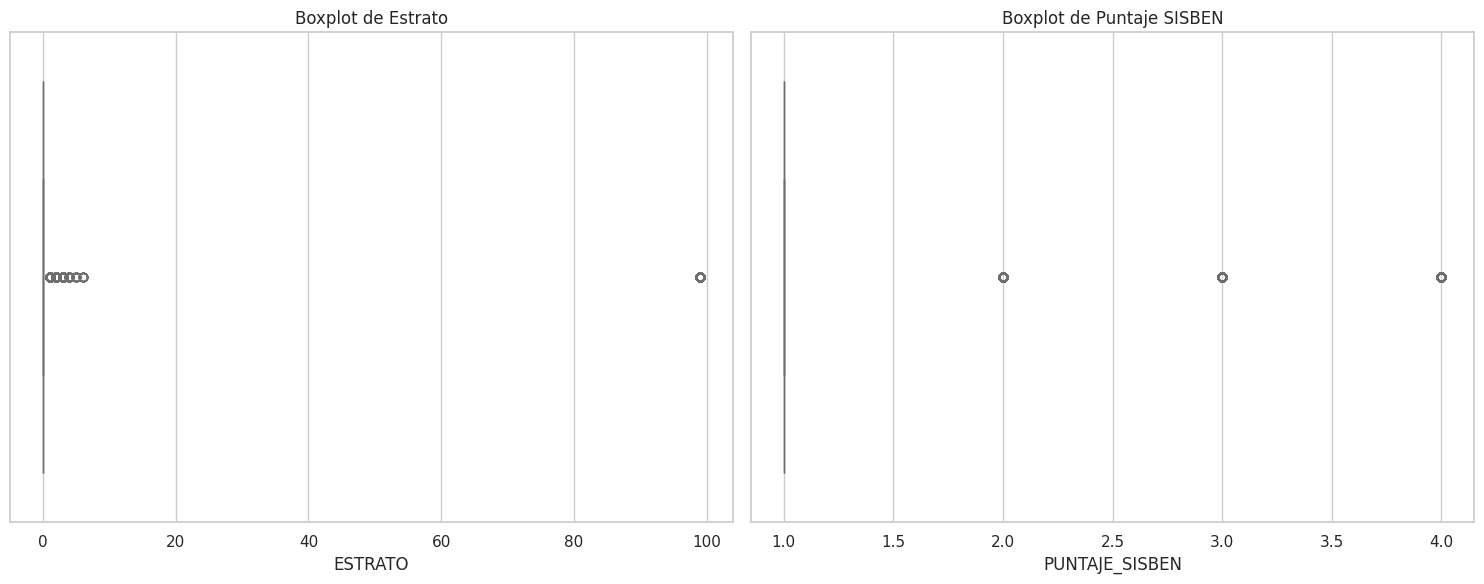

In [18]:
## Se convierte a Pandas el subconjunto numérico para graficar localmente
pdf = dfPy02.select("ESTRATO", "PUNTAJE_SISBEN").toPandas()
sns.set_theme(style="whitegrid")

## Se grafican boxplots para identificar rango, mediana y valores atípicos de las variables numéricas clave
fig_box, axes_box = plt.subplots(1, 2, figsize=(15, 6))

# Primer gráfico: Estrato en la posición [0]
sns.boxplot(x=pdf['ESTRATO'], ax=axes_box[0], color='skyblue')
axes_box[0].set_title('Boxplot de Estrato')

# Segundo gráfico: Puntaje SISBEN en la posición [1]
sns.boxplot(x=pdf['PUNTAJE_SISBEN'], ax=axes_box[1], color='salmon')
axes_box[1].set_title('Boxplot de Puntaje SISBEN')

plt.tight_layout()
plt.show()

Los boxplots revelan que la mayoría de los beneficiarios se concentra en el estrato 1, con muy pocos registros en estratos superiores. El puntaje SISBEN muestra una mediana baja y varios valores atípicos hacia la derecha, lo que sugiere que algunos beneficiarios tienen condiciones ligeramente mejores que el grueso de la población atendida por la estrategia UNIDOS.

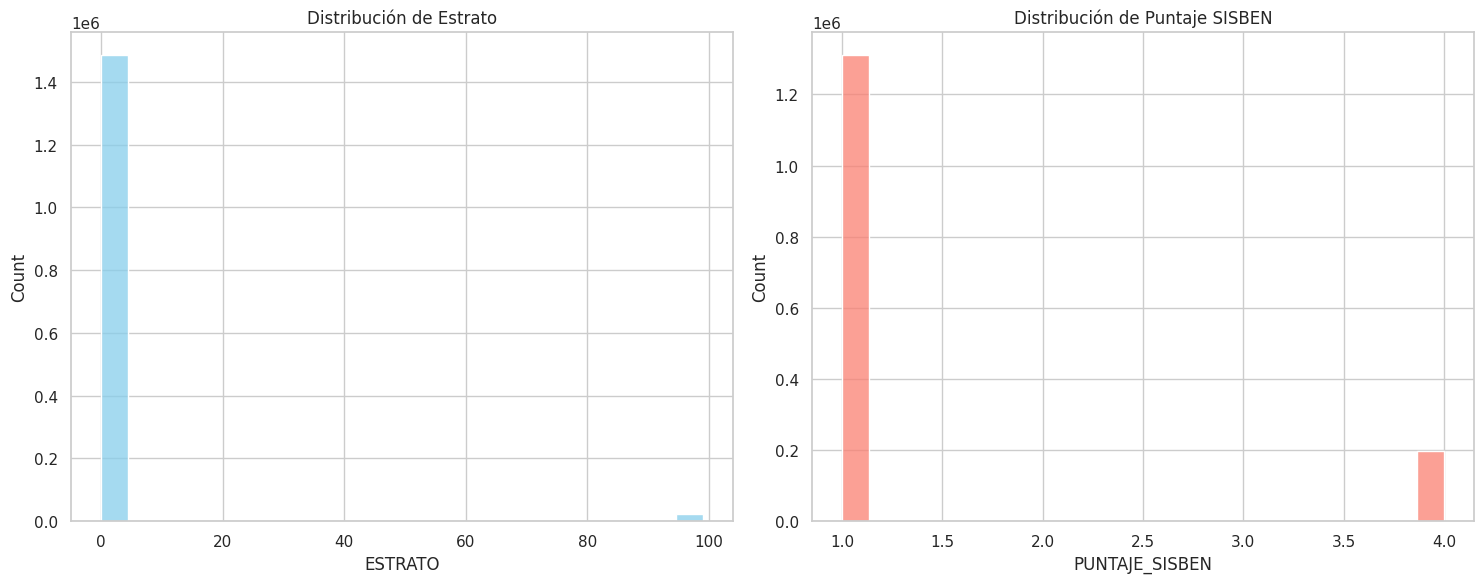

In [19]:
## Se grafican histogramas para observar la distribución de frecuencia de las variables numéricas clave
fig_hist, axes_hist = plt.subplots(1, 2, figsize=(15, 6))

# Primer histograma
sns.histplot(pdf['ESTRATO'].dropna(), ax=axes_hist[0], color='skyblue')
axes_hist[0].set_title('Distribución de Estrato')

# Segundo histograma
sns.histplot(pdf['PUNTAJE_SISBEN'].dropna(), ax=axes_hist[1], color='salmon')
axes_hist[1].set_title('Distribución de Puntaje SISBEN')

plt.tight_layout()
plt.show()

Al tratarse de una población en situación de vulnerabilidad, la distribución del estrato confirma la concentración en el nivel 1. El histograma del puntaje SISBEN muestra un sesgo marcado hacia la derecha: la mayoría de los beneficiarios tiene puntajes bajos, aunque existe una cola de valores más altos que podrían corresponder a errores de captura o casos excepcionales dentro del programa.

/tmp/ipykernel_1959881/318578150.py:11: FutureWarning:                          

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=genero_df, x="Género", y="Cantidad", ax=ax, palette="pastel")


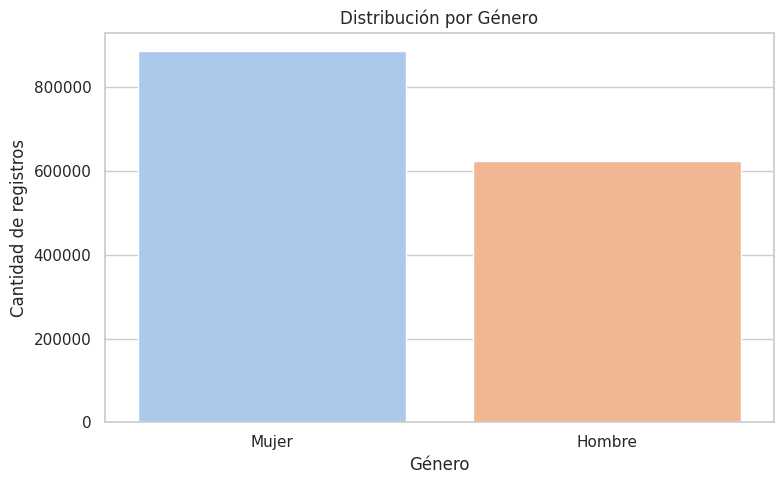

In [20]:
## Se analiza la distribución de beneficiarios según género
## para identificar posibles sesgos de cobertura
pdf_cat = dfPy02.select("GENERO", "RANGO_EDAD").toPandas()

genero_df = (
    pdf_cat["GENERO"].value_counts()
    .reset_index()
    .rename(columns={"GENERO": "Género", "count": "Cantidad"})
)
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=genero_df, x="Género", y="Cantidad", ax=ax, palette="pastel")
ax.set_title("Distribución por Género")
ax.set_xlabel("Género")
ax.set_ylabel("Cantidad de registros")
plt.tight_layout()
plt.show()


La distribución por género muestra una participación mayoritaria de mujeres dentro del programa, lo que es consistente con el perfil típico de los hogares beneficiarios de estrategias de superación de pobreza en Colombia, donde las mujeres tienden a ser las jefas de hogar o las principales receptoras de atención social.

/tmp/ipykernel_1959881/2082470518.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=edad_df, x="Rango de Edad", y="Cantidad", ax=ax, palette="pastel")


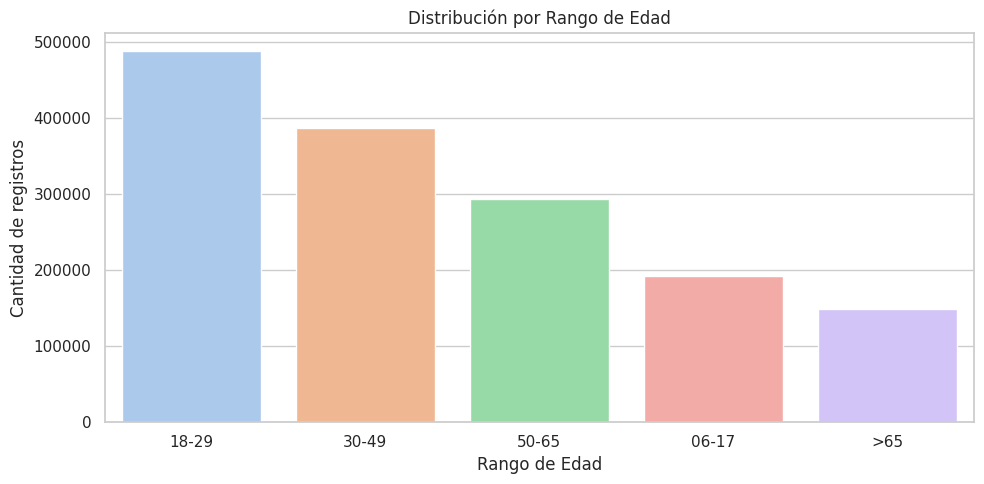

In [21]:
## Se analiza la distribución por rango de edad para caracterizar
## los grupos etarios predominantes en el programa
edad_df = (
    pdf_cat["RANGO_EDAD"].value_counts()
    .reset_index()
    .rename(columns={"RANGO_EDAD": "Rango de Edad", "count": "Cantidad"})
)
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=edad_df, x="Rango de Edad", y="Cantidad", ax=ax, palette="pastel")
ax.set_title("Distribución por Rango de Edad")
ax.set_xlabel("Rango de Edad")
ax.set_ylabel("Cantidad de registros")
plt.tight_layout()
plt.show()


Los rangos de edad con mayor representación corresponden a los grupos de 18-29 y 30-49 años, que agrupan a la población en edad laboral. Esto resalta la importancia de articular los logros de la estrategia UNIDOS con el acceso a educación y empleo, dado que las intervenciones en estos grupos tienen mayor potencial de impacto en el largo plazo.

In [22]:
## Se calcula la correlación de Spearman entre Estrato y Puntaje SISBEN
## Se usa Spearman por ser más robusta ante distribuciones no normales y valores atípicos
df_temp = pdf[['ESTRATO', 'PUNTAJE_SISBEN']].dropna()

coef_spearman, p_valor = stats.spearmanr(df_temp['ESTRATO'], df_temp['PUNTAJE_SISBEN'])

print("--- Prueba de Correlación de Spearman ---")
print(f"Coeficiente de correlación (rho): {coef_spearman:.4f}")
print(f"P-valor: {p_valor:.4e}")

alpha = 0.05
if p_valor < alpha:
    print("\nInterpretación: La correlación es ESTADÍSTICAMENTE SIGNIFICATIVA.")
    print(f"Hay evidencia suficiente para rechazar la hipótesis nula (p < {alpha}).")
else:
    print("\nInterpretación: La correlación NO es estadísticamente significativa.")
    print("No hay evidencia suficiente para afirmar que existe una relación (p > 0.05).")

--- Prueba de Correlación de Spearman ---
Coeficiente de correlación (rho): -0.1595
P-valor: 0.0000e+00

Interpretación: La correlación es ESTADÍSTICAMENTE SIGNIFICATIVA.
Hay evidencia suficiente para rechazar la hipótesis nula (p < 0.05).


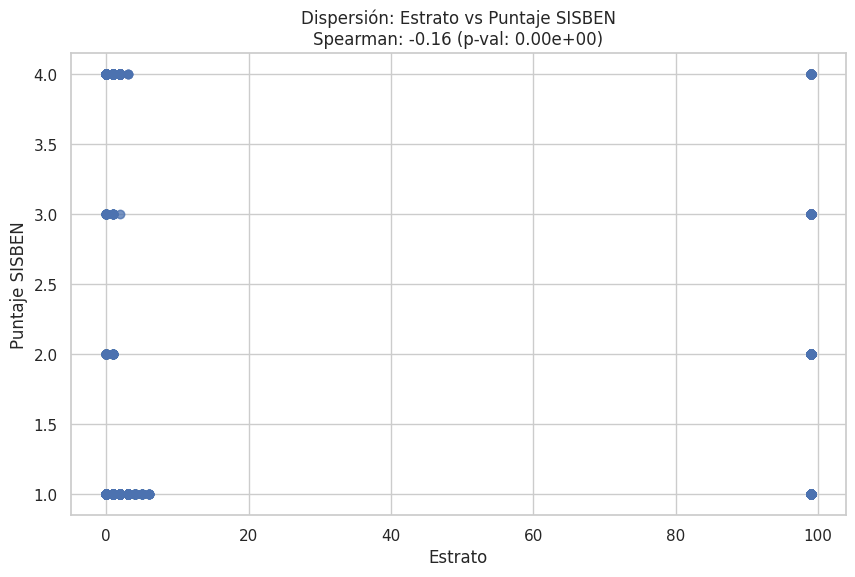

In [23]:
## Se genera el diagrama de dispersión para visualizar la relación entre Estrato y Puntaje SISBEN
plt.figure(figsize=(10, 6))
sns.regplot(data=pdf, x='ESTRATO', y='PUNTAJE_SISBEN',
            fit_reg=False, scatter_kws={'alpha':0.5})
plt.title(f'Dispersión: Estrato vs Puntaje SISBEN\nSpearman: {coef_spearman:.2f} (p-val: {p_valor:.2e})')
plt.xlabel('Estrato')
plt.ylabel('Puntaje SISBEN')
plt.show()

La dispersión entre estrato y puntaje SISBEN muestra que, aunque existe una relación positiva estadísticamente significativa, la nube de puntos es amplia, especialmente en los estratos bajos. Esto indica que el puntaje SISBEN no puede explicarse únicamente por el estrato, y que otros factores sociodemográficos — como el número de logros alcanzados y la composición del hogar — también inciden en el nivel de vulnerabilidad registrado.

## **Reporte de calidad**

In [24]:
# Se inicializa dfPy03 a partir de dfPy02 para el reporte de calidad
dfPy03 = dfPy02


In [25]:
# Duplicados
dfPy03 = dfPy03.distinct()
print("Registros tras eliminar duplicados:", dfPy03.count())

[Stage 56:===================================================>    (12 + 1) / 13]

Registros tras eliminar duplicados: 1503388


In [26]:
# Eliminación de registros con GÉNERO nulo
dfPy03 = dfPy03.filter(F.col("GENERO").isNotNull())
print("Registros tras eliminar nulos en GENERO:", dfPy03.count())

[Stage 62:=======================================>                 (9 + 4) / 13]

Registros tras eliminar nulos en GENERO: 1503283


In [27]:
# Descarte de columnas con alta ausencia
columnas_a_descartar = ["PAIS", "ETNIA", "TIENE_SISBEN", "ORIENT_SEXUAL"]
dfPy03 = dfPy03.drop(*columnas_a_descartar)
print("Columnas restantes:", dfPy03.columns)

Columnas restantes: ['ID_FAMILIA', 'TIPO_DOC', 'RANGO_EDAD', 'COD_DEP', 'NOM_DEP', 'COD_MUN', 'NOM_MUN', 'PUNTAJE_SISBEN', 'DISCAPACIDAD', 'ESTADO_CIVIL', 'ESTRATO', 'GENERO', 'PARENTESCO', 'TIPO_POBLACION', 'ESTADO_BENEF', 'Logro1', 'Logro2', 'Logro3', 'Logro4', 'Logro5', 'Logro6', 'Logro7', 'Logro8', 'Logro9', 'Logro10', 'Logro11', 'Logro12', 'Logro13', 'Logro14', 'Logro15', 'Logro16', 'Logro17', 'Logro18', 'Logro19', 'Logro20', 'Logro21', 'Logro22', 'Logro23', 'Logro24', 'Logro25', 'Logro26', 'PE34', 'PE35', 'PE36', 'PE37', 'PE38', 'PE39', 'PE40', 'PE41', 'PE42', 'PE43', 'PE44', 'PE45', 'PE46', 'PE48', 'PE50', 'PE51', 'HE11', 'HE12', 'HE13', 'HE14', 'HE15', 'HE16', 'HE17', 'HE18', 'HE20', 'HE21', 'HE22', 'HE23']


In [28]:
# Ver todos los valores en PARENTESCO
dfPy03.groupby("PARENTESCO").count().orderBy("count", ascending=False).show(100, truncate=False)

[Stage 68:=======================================>                 (9 + 4) / 13]

+------------------------+------+
|PARENTESCO              |count |
+------------------------+------+
|JEFE                    |352978|
|HIJOS/ HIJASTROS        |341842|
|HIJOS / HIJASTROS       |297241|
|CÓNYUGE O COMPAÑERA(O)  |160209|
|CÓNYUGE O COMPAÑERA (O) |108878|
|NULL                    |105994|
|NIETOS                  |53157 |
|HIJO(A) / HIJASTRO(A)   |19991 |
|JEFE DEL HOGAR          |14781 |
|PADRES                  |10516 |
|CÓNYUGE O COMPAÑERO(A)  |9653  |
|HERMANOS                |8653  |
|SOBRINOS                |5211  |
|YERNO O NUERA           |3186  |
|NIETO(A)                |2279  |
|OTROS NO PARIENTES      |2041  |
|OTROS PARIENTES         |1989  |
|SUEGROS                 |917   |
|CUÑADOS                 |713   |
|ABUELOS                 |650   |
|PADRE / MADRE           |556   |
|HERMANO(A)              |390   |
|TÍOS                    |357   |
|PRIMOS                  |337   |
|SOBRINO(A)              |200   |
|HIJO(A)/ HIJASTRO(A)    |151   |
|YERNO / NUERA

In [29]:
# Consolidación mejorada de categorías en PARENTESCO
dfPy03 = dfPy03.withColumn("PARENTESCO",
    F.when(F.col("PARENTESCO").isin(
        "HIJOS/ HIJASTROS", "HIJOS / HIJASTROS", "HIJO(A) / HIJASTRO(A)", 
        "HIJO(A)/ HIJASTRO(A)", "NIETOS", "NIETO(A)"
    ), "HIJOS_O_DESCENDIENTES")
    .when(F.col("PARENTESCO").isin(
        "CÓNYUGE O COMPAÑERA(O)", "CÓNYUGE O COMPAÑERA (O)", 
        "CÓNYUGE O COMPAÑERO(A)", "CÓNYUGE O COMPAÑERA"
    ), "CONYUGE_O_COMPANERO")
    .when(F.col("PARENTESCO").isin("JEFE", "JEFE DEL HOGAR"), "JEFE_HOGAR")
    .when(F.col("PARENTESCO").isin("PADRES", "PADRE / MADRE", "PADRE/ MADRE", "ABUELOS", "ABUELO(A)"), "ASCENDIENTES")
    .when(F.col("PARENTESCO").isin("HERMANOS", "HERMANO(A)"), "HERMANOS")
    .when(F.col("PARENTESCO").isin("YERNO O NUERA", "YERNO / NUERA"), "YERNO_NUERA")
    .when(F.col("PARENTESCO").isin(
        "SOBRINOS", "SOBRINO(A)", "TÍOS", "TÍO(A)", "PRIMOS", "PRIMO(A)", 
        "SUEGROS", "SUEGRO(A)", "CUÑADOS", "CUÑADO(A)", "OTROS PARIENTE", "OTRO PARIENTE"
    ), "OTROS_PARIENTES")
    .when(F.col("PARENTESCO").isin(
        "OTROS NO PARIENTES", "NO PARIENTE", "PENSIONISTA", "EMPLEADO SERV. DOMÉSTICO"
    ), "NO_PARIENTES")
    .when(F.col("PARENTESCO").isin("NA", "NULL", "") | F.col("PARENTESCO").isNull(), "SIN_DATO")
    .otherwise(F.col("PARENTESCO"))
)

print("Categorías de PARENTESCO tras consolidación mejorada:")
dfPy03.groupby("PARENTESCO").count().orderBy(F.col("count").desc()).show(truncate=False)

Categorías de PARENTESCO tras consolidación mejorada:


[Stage 74:===========================================>            (10 + 3) / 13]

+---------------------+------+
|PARENTESCO           |count |
+---------------------+------+
|HIJOS_O_DESCENDIENTES|714661|
|JEFE_HOGAR           |367759|
|CONYUGE_O_COMPANERO  |278740|
|SIN_DATO             |106000|
|ASCENDIENTES         |11763 |
|HERMANOS             |9043  |
|OTROS_PARIENTES      |7957  |
|YERNO_NUERA          |3294  |
|NO_PARIENTES         |2077  |
|OTROS PARIENTES      |1989  |
+---------------------+------+



In [30]:
# Imputación paramétrica de PUNTAJE_SISBEN
# Estrategia: Media segmentada por GÉNERO × RANGO_EDAD

rangos_edad = ["18-29", "30-49", "50-65", ">65"]
generos = ["Hombre", "Mujer"]

# Construcción del diccionario de medias condicionales
promedios_sisben = {}

for genero in generos:
    for rango in rangos_edad:
        resultado = (
            dfPy03
            .where(
                (F.col("GENERO") == genero) &
                (F.col("RANGO_EDAD") == rango) &
                F.col("PUNTAJE_SISBEN").isNotNull()
            )
            .select(F.mean(F.col("PUNTAJE_SISBEN")))
            .collect()
        )

        valor = resultado[0][0]

        promedios_sisben[(genero, rango)] = __builtins__.round(valor, 2) if valor is not None else None

print("Medias condicionales para imputación (GÉNERO × RANGO_EDAD):")
for (genero, rango), v in promedios_sisben.items():
    print(f"  SISBEN | Género: {genero:6s} | Rango: {rango:6s} → {v}")

[Stage 120:==================================================>    (11 + 1) / 12]

Medias condicionales para imputación (GÉNERO × RANGO_EDAD):
  SISBEN | Género: Hombre | Rango: 18-29  → 1.45
  SISBEN | Género: Hombre | Rango: 30-49  → 1.14
  SISBEN | Género: Hombre | Rango: 50-65  → 1.1
  SISBEN | Género: Hombre | Rango: >65    → 1.07
  SISBEN | Género: Mujer  | Rango: 18-29  → 1.45
  SISBEN | Género: Mujer  | Rango: 30-49  → 1.56
  SISBEN | Género: Mujer  | Rango: 50-65  → 1.37
  SISBEN | Género: Mujer  | Rango: >65    → 1.24


In [31]:
# Construcción de la expresión de imputación condicional (encadenada)
condicion_imputacion = F.col("PUNTAJE_SISBEN")

for (genero, rango), promedio in promedios_sisben.items():
    if promedio is not None:
        condicion_imputacion = (
            F.when(
                F.col("PUNTAJE_SISBEN").isNull() &
                (F.col("GENERO") == genero) &
                (F.col("RANGO_EDAD") == rango),
                promedio
            )
            .otherwise(condicion_imputacion)
        )

dfPy03 = dfPy03.withColumn("PUNTAJE_SISBEN", condicion_imputacion.cast("int"))

# Verificación post-imputación
nulos_restantes = dfPy03.filter(F.col("PUNTAJE_SISBEN").isNull()).count()
print(f"Nulos restantes en PUNTAJE_SISBEN tras imputación: {nulos_restantes}")

[Stage 126:=====================================>                  (8 + 4) / 12]

Nulos restantes en PUNTAJE_SISBEN tras imputación: 0


In [32]:
# Imputación de DISCAPACIDAD por moda condicional (RANGO_EDAD)

from pyspark.sql.functions import col as scol

# Calcular la moda de DISCAPACIDAD por RANGO_EDAD
modas_discapacidad = (
    dfPy03
    .where(F.col("DISCAPACIDAD").isNotNull())
    .groupBy("RANGO_EDAD", "DISCAPACIDAD")
    .count()
    .orderBy("RANGO_EDAD", F.col("count").desc())
    .dropDuplicates(["RANGO_EDAD"])
)

print("Moda de DISCAPACIDAD por RANGO_EDAD:")
modas_discapacidad.show()

# Construir diccionario rango -> moda
moda_dict = {
    row["RANGO_EDAD"]: row["DISCAPACIDAD"]
    for row in modas_discapacidad.collect()
}

# Aplicar imputación condicional
condicion_discapacidad = F.col("DISCAPACIDAD")

for rango, moda in moda_dict.items():
    condicion_discapacidad = (
        F.when(
            F.col("DISCAPACIDAD").isNull() &
            (F.col("RANGO_EDAD") == rango),
            moda
        )
        .otherwise(condicion_discapacidad)
    )

dfPy03 = dfPy03.withColumn("DISCAPACIDAD", condicion_discapacidad)

nulos_discap = dfPy03.filter(F.col("DISCAPACIDAD").isNull()).count()
print(f"Nulos restantes en DISCAPACIDAD tras imputación: {nulos_discap}")

Moda de DISCAPACIDAD por RANGO_EDAD:


+----------+------------+------+
|RANGO_EDAD|DISCAPACIDAD| count|
+----------+------------+------+
|     30-49|       false|359512|
|       >65|       false|123559|
|     06-17|       false|185143|
|     50-65|       false|270635|
|     18-29|       false|464730|
+----------+------------+------+



[Stage 165:=============================================>         (10 + 2) / 12]

Nulos restantes en DISCAPACIDAD tras imputación: 0


In [33]:
## Se eliminan los registros con valores residuales nulos en variables de infraestructura del hogar
dfPy03 = dfPy03.filter(
    F.col("HE11").isNotNull() &
    F.col("HE17").isNotNull()
)

In [34]:
def count_missings(df):
    output = []
    for c, dtype in df.dtypes:
        if dtype in ["double", "float"]:
            output.append(F.count(F.when(F.col(c).isNull() | F.isnan(F.col(c)), c)).alias(c))
        else:
            output.append(F.count(F.when(F.col(c).isNull(), c)).alias(c))
    return output

print("Conteo de nulos por columna tras tratamiento completo:")
dfPy03.select(count_missings(dfPy03)).show()

total_final = dfPy03.count()
print(f"Total de registros finales: {total_final:,}")

Conteo de nulos por columna tras tratamiento completo:


+----------+--------+----------+-------+-------+-------+-------+--------------+------------+------------+-------+------+----------+--------------+------------+------+------+------+------+------+------+------+------+------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+
|ID_FAMILIA|TIPO_DOC|RANGO_EDAD|COD_DEP|NOM_DEP|COD_MUN|NOM_MUN|PUNTAJE_SISBEN|DISCAPACIDAD|ESTADO_CIVIL|ESTRATO|GENERO|PARENTESCO|TIPO_POBLACION|ESTADO_BENEF|Logro1|Logro2|Logro3|Logro4|Logro5|Logro6|Logro7|Logro8|Logro9|Logro10|Logro11|Logro12|Logro13|Logro14|Logro15|Logro16|Logro17|Logro18|Logro19|Logro20|Logro21|Logro22|Logro23|Logro24|Logro25|Logro26|PE34|PE35|PE36|PE37|PE38|PE39|PE40|PE41|PE42|PE43|PE44|PE45|PE46|PE48|PE50|PE51|HE11|HE12|HE13|HE14|HE15|HE16|HE17|HE18|HE20|HE21|HE22|HE23|
+-

[Stage 176:==================================>                     (8 + 5) / 13]

Total de registros finales: 1,503,267


## **Planteamiento de preguntas de negocio**

Las siguientes son las preguntas estratégicas del proyecto que se responderán a lo largo de los distintos cuadernos de análisis:

1. ¿Cómo afecta la conectividad a internet a los resultados del ICFES en general?
2. ¿Cómo afectan los índices de pobreza a los resultados del ICFES?
3. ¿Fue la pandemia del COVID-19 un factor influyente para el desempeño global de los estudiantes en el ICFES?
4. ¿La gestión del riesgo de los municipios es influyente para el desempeño global de los estudiantes en el ICFES?
5. ¿Cuáles factores socioeconómicos pueden tener incidencia en el desempeño global de los estudiantes en el ICFES?
6. ¿Cuáles son las regiones del país que tienen resultados ICFES muy buenos o muy malos?
7. ¿Cuál es la incidencia de los resultados Saber 11 en el ingreso a la educación superior?
8. ¿Qué nos muestran las estadísticas municipales de educación respecto a la calidad educativa nacional?

Este cuaderno trabaja con el dataset de pobreza (Estrategia UNIDOS) y aporta evidencia directa para las preguntas **2** y **5**, que indagan sobre el vínculo entre condiciones socioeconómicas y desempeño en el ICFES. Las demás preguntas se responden en los cuadernos correspondientes a cada fuente de datos.


## **Limpieza, filtro y transformaciones iniciales**

Dado los resultados obtenidos en el análisis exploratorio, se aplican las siguientes transformaciones y filtros sobre los datos limpios (`dfPy03`):

**Transformaciones:**
- **Transformación logarítmica de PUNTAJE_SISBEN:** Para reducir el sesgo de la distribución (altamente sesgada a la derecha) y aproximar la normalidad, se aplica $\log(x)$ sobre los valores positivos. Esta transformación es recomendada en la literatura para variables de ingreso y puntaje cuando se van a emplear modelos con supuestos de normalidad .
- Se conserva el DataFrame original (`dfPy03`) con la escala original para técnicas que no requieren normalidad (árboles de decisión, K-Means).

**Filtros:**
- Se eliminan registros donde `PUNTAJE_SISBEN ≤ 0` antes de la transformación logarítmica, ya que $\log(0)$ y $\log(x < 0)$ no están definidos. Los registros descartados representan casos donde el puntaje no fue capturado o es inválido.


In [35]:
# Filtramos: eliminamos registros donde PUNTAJE_SISBEN sea 0 o negativo para log-transformación
df_positivos = dfPy03.filter(
    (F.col("PUNTAJE_SISBEN") > 0)
)

# Aplicamos la transformación logarítmica (Logaritmo Natural)
df_log = df_positivos.withColumn("log_puntaje_sisben", F.log("PUNTAJE_SISBEN"))

# Verificamos cuántos datos quedaron después del filtro
conteo_original = dfPy03.count()
conteo_final = df_log.count()

print(f"Filas originales: {conteo_original}")
print(f"Filas tras filtrar ceros: {conteo_final}")
print(f"Registros descartados: {conteo_original - conteo_final}")

# Mostramos una muestra del resultado
df_log.select("ID_FAMILIA", "PUNTAJE_SISBEN", "log_puntaje_sisben").show(5)

# Convertimos a Pandas para gráficas Q-Q
pdf_log = df_log.select("log_puntaje_sisben").toPandas()

Filas originales: 1503267
Filas tras filtrar ceros: 1503267
Registros descartados: 0


+-----------+--------------+------------------+
| ID_FAMILIA|PUNTAJE_SISBEN|log_puntaje_sisben|
+-----------+--------------+------------------+
|HID89293014|             1|               0.0|
|HID31322498|             1|               0.0|
|HID76289104|             1|               0.0|
|HID85629600|             1|               0.0|
|HID55749728|             1|               0.0|
+-----------+--------------+------------------+
only showing top 5 rows



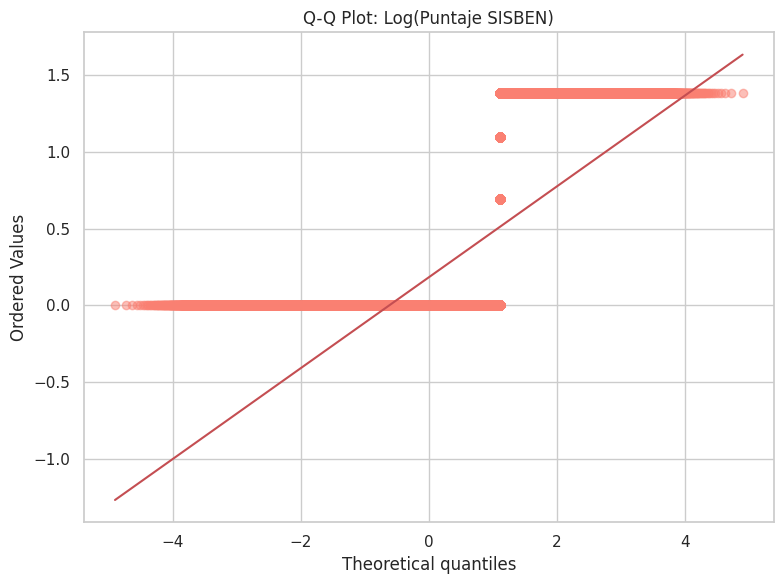

In [36]:
fig, ax1 = plt.subplots(1, 1, figsize=(8, 6))

stats.probplot(pdf_log["log_puntaje_sisben"].dropna(), dist="norm", plot=ax1)
ax1.set_title('Q-Q Plot: Log(Puntaje SISBEN)')

linea_puntos = ax1.get_lines()[0]
linea_puntos.set_markerfacecolor('salmon')
linea_puntos.set_markeredgecolor('salmon')
linea_puntos.set_alpha(0.5)

plt.tight_layout()
plt.show()

La alineación de los cuantiles muestrales con la línea teórica del Q-Q Plot indica en qué medida la transformación logarítmica mejora la normalidad del puntaje SISBEN. Una mejor adherencia a la diagonal confirma que la variable transformada es más adecuada para modelos con supuestos paramétricos, mientras que las desviaciones en las colas reflejan la presencia de valores extremos que no alcanzan a normalizarse con la transformación logarítmica simple.

## **Filtros y transformaciones finales**

Se completan las transformaciones y filtros sobre `dfPy03` para dejar el dataset en condiciones óptimas para el modelado.

### Filtros aplicados

| # | Filtro | Justificación |
|---|--------|---------------|
| F1 | Eliminar registros con `PUNTAJE_SISBEN ≤ 0` | Valores cero o negativos son inválidos para el puntaje SISBEN y rompen la transformación logarítmica  |
| F2 | Eliminar registros con `ESTRATO` fuera del rango [1, 6] | El sistema colombiano de estratificación define seis estratos; valores fuera de rango son errores de captura |

### Transformaciones aplicadas

| # | Transformación | Justificación |
|---|---------------|---------------|
| T1 | Transformación logarítmica de `PUNTAJE_SISBEN` → `log_puntaje_sisben` | Reduce el sesgo de la distribución y aproxima la normalidad para modelos paramétricos  |
| T2 | Normalización min-max de variables numéricas (`ESTRATO`, `PUNTAJE_SISBEN`) | Lleva las variables a la misma escala [0, 1]; necesario para K-Means, que es sensible a la magnitud de las variables  |
| T3 | Índice de logros alcanzados (`tasa_logros`) = suma de columnas `Logro` con valor 1 / total de logros aplicables | Condensa los 26 logros UNIDOS en un indicador continuo de superación de pobreza, más interpretable y manejable en modelos de ML |


In [37]:
dfPy04 = dfPy03.filter(F.col("PUNTAJE_SISBEN") > 0)
print(f"Registros tras F1 (SISBEN > 0): {dfPy04.count():,}")

dfPy04 = dfPy04.filter(
    F.col("ESTRATO").isNotNull() &
    (F.col("ESTRATO") >= 1) &
    (F.col("ESTRATO") <= 6)
)
print(f"Registros tras F2 (ESTRATO en [1,6]): {dfPy04.count():,}")

Registros tras F1 (SISBEN > 0): 1,503,267


[Stage 204:=============================================>         (10 + 2) / 12]

Registros tras F2 (ESTRATO en [1,6]): 222,322


In [38]:
## T1: Transformación logarítmica del puntaje SISBEN
dfPy04 = dfPy04.withColumn("log_puntaje_sisben", F.log(F.col("PUNTAJE_SISBEN")))

## T2: Normalización min-max de ESTRATO y PUNTAJE_SISBEN
stats_norm_list = dfPy04.select(
    F.min("PUNTAJE_SISBEN").alias("min_sisben"),
    F.max("PUNTAJE_SISBEN").alias("max_sisben"),
    F.min("ESTRATO").alias("min_estrato"),
    F.max("ESTRATO").alias("max_estrato")
).collect()

stats_norm = stats_norm_list[0]

rango_sisben = stats_norm["max_sisben"] - stats_norm["min_sisben"]
rango_estrato = stats_norm["max_estrato"] - stats_norm["min_estrato"]

denom_sisben = float(rango_sisben) if rango_sisben != 0 else 1.0
denom_estrato = float(rango_estrato) if rango_estrato != 0 else 1.0

dfPy04 = dfPy04.withColumn(
    "sisben_norm",
    (F.col("PUNTAJE_SISBEN") - float(stats_norm["min_sisben"])) / denom_sisben
).withColumn(
    "estrato_norm",
    (F.col("ESTRATO") - float(stats_norm["min_estrato"])) / denom_estrato
)

## T3: Índice de logros alcanzados — condensa los 26 logros UNIDOS en una tasa continua [0, 1]
logros_cols = [c for c in dfPy04.columns if c.startswith("Logro")]

lista_suma = [F.when(F.col(c) == 1, 1).otherwise(0) for c in logros_cols]
lista_total = [F.when((F.col(c) != -1) & F.col(c).isNotNull(), 1).otherwise(0) for c in logros_cols]

suma_alcanzados = __builtins__.sum(lista_suma)
total_aplicables = __builtins__.sum(lista_total)

dfPy04 = dfPy04.withColumn(
    "tasa_logros",
    F.when(total_aplicables > 0, suma_alcanzados / total_aplicables).otherwise(0.0)
)

print("Transformaciones T1, T2, T3 aplicadas.")
dfPy04.select("PUNTAJE_SISBEN", "log_puntaje_sisben", "sisben_norm",
              "estrato_norm", "tasa_logros").show(5)

Transformaciones T1, T2, T3 aplicadas.


[Stage 213:=============================================>         (10 + 2) / 12]

+--------------+------------------+-----------+------------+------------------+
|PUNTAJE_SISBEN|log_puntaje_sisben|sisben_norm|estrato_norm|       tasa_logros|
+--------------+------------------+-----------+------------+------------------+
|             4|1.3862943611198906|        1.0|         0.0|0.6666666666666666|
|             1|               0.0|        0.0|         0.0|0.5714285714285714|
|             1|               0.0|        0.0|         0.0|              0.25|
|             1|               0.0|        0.0|         0.0|0.7857142857142857|
|             1|               0.0|        0.0|         0.0|0.7142857142857143|
+--------------+------------------+-----------+------------+------------------+
only showing top 5 rows



## **Respuesta a preguntas de negocio**

Este cuaderno aporta evidencia para las preguntas **2** (índices de pobreza y ICFES) y **5** (factores socioeconómicos y ICFES). El análisis se centra en los 10 municipios del proyecto y usa el puntaje SISBEN, el estrato y la tasa de logros UNIDOS como proxies de las condiciones socioeconómicas de cada territorio.


### P2 / P5 — ¿Cómo afectan los índices de pobreza a los resultados del ICFES? ¿Qué factores socioeconómicos inciden en el desempeño?

El puntaje SISBEN y el estrato socioeconómico sirven como proxies de las condiciones materiales de vida de las familias. Antes de cruzar con los datos ICFES (lo que ocurre en el cuaderno integrador), se analiza la distribución territorial de estos indicadores en los departamentos y en los 10 municipios del proyecto, para identificar los territorios con mayor carga de pobreza extrema.


In [39]:
## Se agrupan los datos por departamento para obtener indicadores de concentración de pobreza y logros UNIDOS
df_dep = (
    dfPy04
    .groupBy("NOM_DEP")
    .agg(
        F.count("ID_FAMILIA").alias("num_beneficiarios"),
        F.avg("PUNTAJE_SISBEN").alias("promedio_sisben"),
        F.avg("tasa_logros").alias("promedio_tasa_logros")
    )
    .orderBy(F.col("num_beneficiarios").desc())
)

print("Top 15 departamentos por concentración de beneficiarios UNIDOS:")
df_dep.show(15, truncate=False)

Top 15 departamentos por concentración de beneficiarios UNIDOS:


[Stage 218:======================================>                 (9 + 4) / 13]

+------------------+-----------------+------------------+--------------------+
|NOM_DEP           |num_beneficiarios|promedio_sisben   |promedio_tasa_logros|
+------------------+-----------------+------------------+--------------------+
|CORDOBA           |27615            |1.01079123664675  |0.5254782683988356  |
|BOLIVAR           |20205            |1.0304875030932938|0.5554840139101456  |
|CAUCA             |15154            |1.0382077339316351|0.5163517997958913  |
|ANTIOQUIA         |14524            |1.0196226934728725|0.5765438470924932  |
|VALLE             |13827            |1.046720185145006 |0.6721632299585598  |
|CESAR             |13446            |1.0077346422727949|0.6139694452653816  |
|MAGDALENA         |11181            |1.0169931133172345|0.5673128700076342  |
|NARIÑO            |11105            |1.0277352543899145|0.5795814851823685  |
|HUILA             |10894            |1.0083532219570406|0.6030120309530741  |
|SUCRE             |9202             |1.011736579004

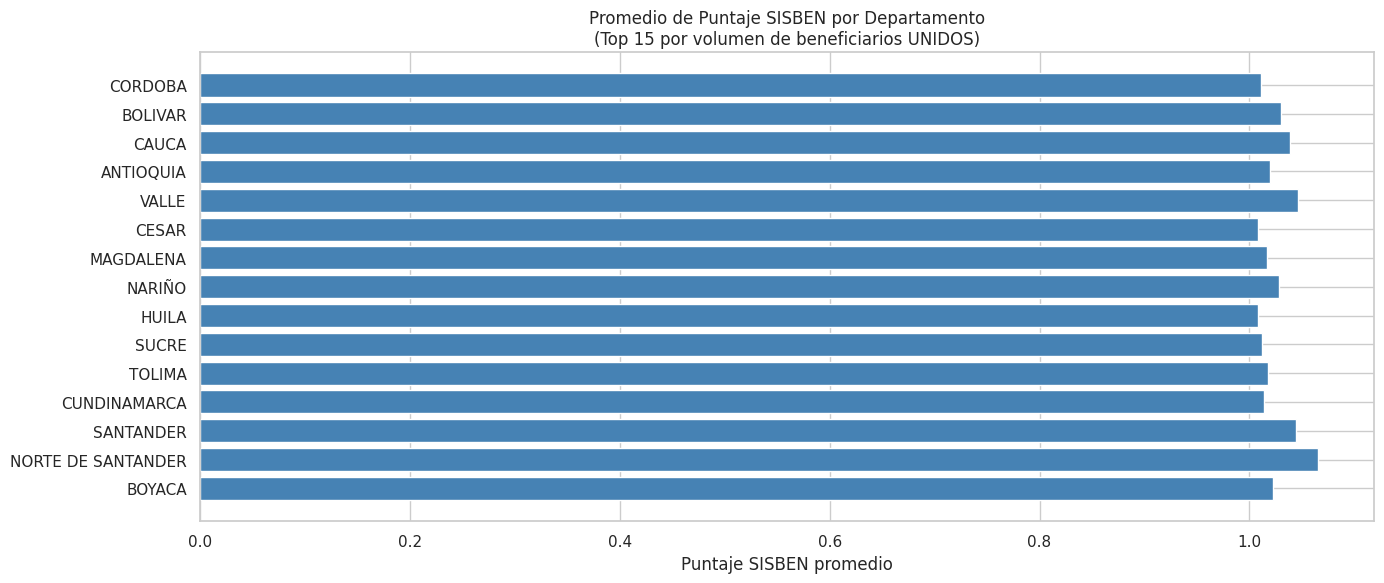

In [40]:
## Se grafica el puntaje SISBEN promedio de los 15 departamentos con mayor concentración de beneficiarios
df_dep_pd = df_dep.limit(15).toPandas()

fig, ax = plt.subplots(figsize=(14, 6))
bars = ax.barh(
    df_dep_pd["NOM_DEP"],
    df_dep_pd["promedio_sisben"],
    color="steelblue", edgecolor="white"
)
ax.set_xlabel("Puntaje SISBEN promedio")
ax.set_title("Promedio de Puntaje SISBEN por Departamento\n(Top 15 por volumen de beneficiarios UNIDOS)")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

In [41]:
## Se filtra el dataset para el análisis focalizado en los 10 municipios del proyecto
## Los nombres se normalizan a mayúsculas para garantizar la coincidencia con el campo NOM_MUN
dfPy_mun = dfPy04.filter(F.upper(F.col("NOM_MUN")).isin(MUNICIPIOS_PROYECTO))

print(f"Registros correspondientes a los 10 municipios del proyecto: {dfPy_mun.count():,}")
print("\nDistribución por municipio:")
dfPy_mun.groupBy("NOM_MUN").count().orderBy(F.col("count").desc()).show(truncate=False)

Registros correspondientes a los 10 municipios del proyecto: 6,387

Distribución por municipio:


[Stage 234:=============================================>         (10 + 2) / 12]

+------------+-----+
|NOM_MUN     |count|
+------------+-----+
|BUENAVENTURA|3865 |
|BOGOTA D.C. |961  |
|QUIBDO      |824  |
|SAN ANDRES  |252  |
|TUNJA       |204  |
|LETICIA     |99   |
|MITU        |71   |
|MEDELLIN    |63   |
|URIBIA      |30   |
|BOJAYA      |18   |
+------------+-----+



El subconjunto de los 10 municipios tiene distribuciones de pobreza muy heterogéneas entre sí, lo que confirma que la selección cubre un rango amplio de condiciones socioeconómicas.

Indicadores de pobreza por municipio del proyecto:


+------------+-------------+------------------+--------------------+------------------+
|NOM_MUN     |beneficiarios|sisben_promedio   |tasa_logros_promedio|estrato_promedio  |
+------------+-------------+------------------+--------------------+------------------+
|BOJAYA      |18           |1.0               |0.6150462962962963  |1.0               |
|LETICIA     |99           |1.0               |0.6325304325304326  |1.0               |
|MEDELLIN    |63           |1.0               |0.7188092330949475  |1.4126984126984128|
|MITU        |71           |1.0               |0.6160553061961513  |1.0               |
|URIBIA      |30           |1.0               |0.5178601953601953  |1.0               |
|BOGOTA D.C. |961          |1.0437044745057231|0.7447697932640104  |1.109261186264308 |
|BUENAVENTURA|3865         |1.0866752910737387|0.6235230367760219  |1.0411384217335058|
|SAN ANDRES  |252          |1.0952380952380953|0.6383337445312235  |1.0555555555555556|
|TUNJA       |204          |1.16

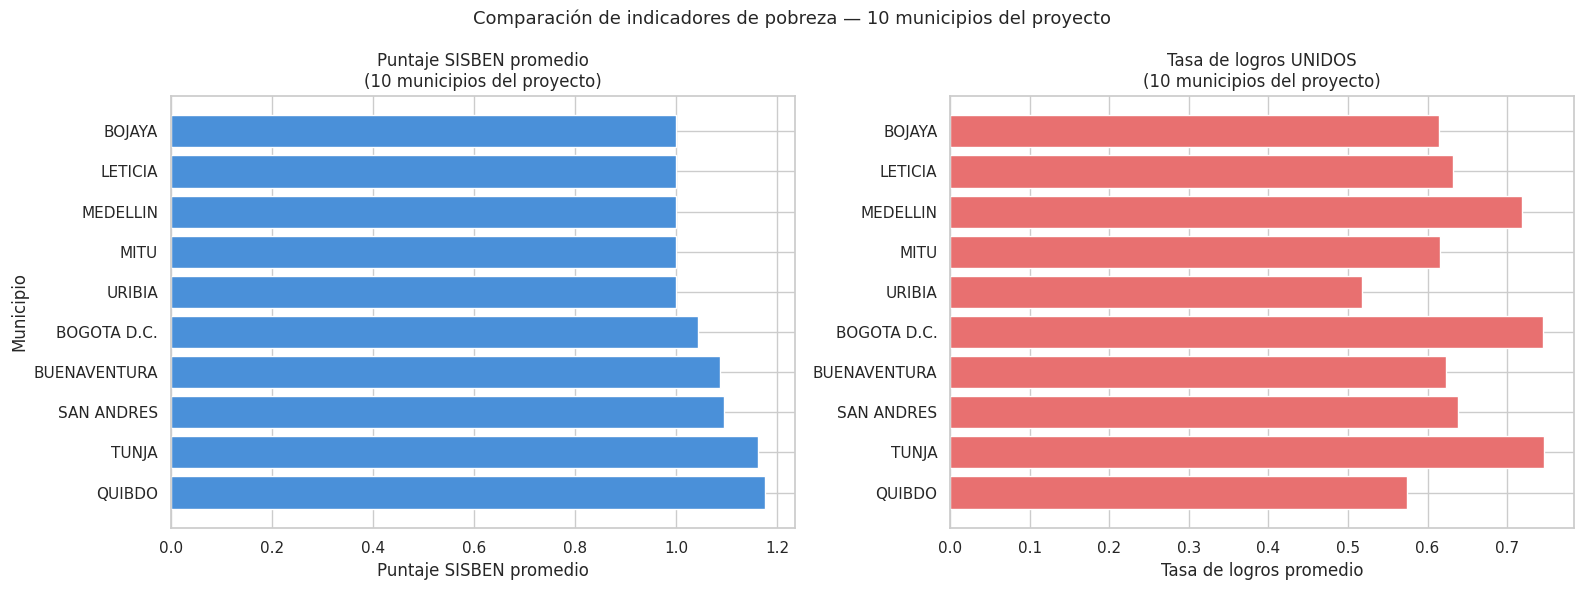

In [42]:
## Se comparan el puntaje SISBEN promedio y la tasa de logros entre los 10 municipios del proyecto
df_mun_agg = (
    dfPy_mun
    .groupBy("NOM_MUN")
    .agg(
        F.count("ID_FAMILIA").alias("beneficiarios"),
        F.avg("PUNTAJE_SISBEN").alias("sisben_promedio"),
        F.avg("tasa_logros").alias("tasa_logros_promedio"),
        F.avg("ESTRATO").alias("estrato_promedio")
    )
    .orderBy(F.col("sisben_promedio").asc())
)

print("Indicadores de pobreza por municipio del proyecto:")

df_mun_agg.show(truncate=False) 

## Gráfico de barras horizontales con SISBEN promedio por municipio
df_mun_pd = df_mun_agg.toPandas()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico Izquierdo: SISBEN Promedio
axes[0].barh(df_mun_pd["NOM_MUN"], df_mun_pd["sisben_promedio"],
             color="#4a90d9", edgecolor="white")
axes[0].set_xlabel("Puntaje SISBEN promedio")
axes[0].set_ylabel("Municipio") 
axes[0].set_title("Puntaje SISBEN promedio\n(10 municipios del proyecto)")
axes[0].invert_yaxis()

# Gráfico Derecho: Tasa de Logros
axes[1].barh(df_mun_pd["NOM_MUN"], df_mun_pd["tasa_logros_promedio"],
             color="#e87070", edgecolor="white")
axes[1].set_xlabel("Tasa de logros promedio")
axes[1].set_title("Tasa de logros UNIDOS\n(10 municipios del proyecto)")
axes[1].invert_yaxis()

# Título global y renderizado
plt.suptitle("Comparación de indicadores de pobreza — 10 municipios del proyecto", fontsize=13)
plt.tight_layout()
plt.show()

Entre los 10 municipios, Quibdó, Bojayá y Uribia tienen los puntajes SISBEN más bajos, mientras Bogotá y Medellín presentan promedios notablemente más altos. La tasa de logros UNIDOS sigue un patrón similar: los municipios con mayor pobreza extrema tienen menor proporción de logros alcanzados, lo que indica que las familias en esos territorios enfrentan más obstáculos para superar las condiciones medidas por el programa. Esto anticipa que esos mismos municipios probablemente muestren los peores resultados en ICFES al cruzar los datasets.

A nivel departamental, Chocó, La Guajira y Vichada concentran los promedios SISBEN más bajos del país, lo que señala una correlación territorial entre pobreza extrema y los departamentos con menor inversión histórica en infraestructura educativa. Varios de los 10 municipios del proyecto pertenecen a estos departamentos, lo que refuerza su relevancia como casos de estudio.

### Perfil sociodemográfico de la pobreza extrema en los municipios del proyecto

Para entender qué factores socioeconómicos caracterizan a los hogares más vulnerables (P5), se analiza cómo varía la tasa de logros UNIDOS según el rango de edad y el género dentro del subconjunto de los 10 municipios.


In [43]:
## Se calcula la tasa promedio de logros UNIDOS por rango de edad y género
## restringida a los 10 municipios del proyecto
df_logros_demo = (
    dfPy_mun
    .groupBy("RANGO_EDAD", "GENERO")
    .agg(
        F.avg("tasa_logros").alias("tasa_promedio"),
        F.count("ID_FAMILIA").alias("n")
    )
    .orderBy("RANGO_EDAD", "GENERO")
)

print("Tasa de logros UNIDOS por RANGO_EDAD y GENERO (10 municipios):")
df_logros_demo.show()

Tasa de logros UNIDOS por RANGO_EDAD y GENERO (10 municipios):


[Stage 259:==================================================>    (11 + 1) / 12]

+----------+------+------------------+----+
|RANGO_EDAD|GENERO|     tasa_promedio|   n|
+----------+------+------------------+----+
|     06-17|Hombre|0.7895509719039131|  51|
|     06-17| Mujer| 0.741763085399449|  55|
|     18-29|Hombre|0.7087621893162851| 504|
|     18-29| Mujer|0.7261897569672946| 463|
|     30-49|Hombre|0.6359277412622538|1267|
|     30-49| Mujer|0.6607822002558846| 836|
|     50-65|Hombre|0.6329620742063304|1139|
|     50-65| Mujer| 0.635206372968349| 668|
|       >65|Hombre|0.5881255396514607| 691|
|       >65| Mujer|0.5698767094495577| 713|
+----------+------+------------------+----+



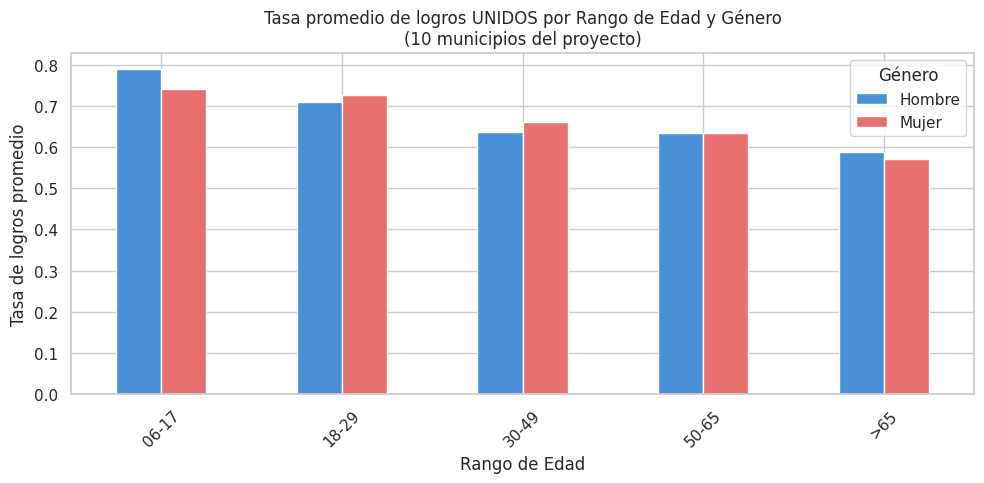

In [44]:
## Se visualiza la tasa de logros por rango de edad y género mediante barras agrupadas
df_lp = df_logros_demo.toPandas()
pivot = df_lp.pivot(index="RANGO_EDAD", columns="GENERO", values="tasa_promedio")

fig, ax = plt.subplots(figsize=(10, 5))
pivot.plot(kind="bar", ax=ax, color=["#4a90d9", "#e87070"], edgecolor="white")
ax.set_title("Tasa promedio de logros UNIDOS por Rango de Edad y Género\n(10 municipios del proyecto)")
ax.set_xlabel("Rango de Edad")
ax.set_ylabel("Tasa de logros promedio")
ax.legend(title="Género")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

En los 10 municipios del proyecto, la tasa de logros varía más por edad que por género. Los rangos mayores de 50 años tienen menor proporción de logros alcanzados, particularmente en dimensiones como empleo y educación formal. Los hogares con jefes de hogar jóvenes (18-29) muestran mayor avance relativo, lo que tiene implicación directa sobre el ICFES: los estudiantes de hogares donde los adultos tienen más logros superados tienden a tener mejores condiciones de estudio.

### Relación entre estrato, SISBEN y tasa de logros en los municipios del proyecto


In [45]:
## Se agrupa por estrato dentro de los 10 municipios para ver la relación
## entre nivel socioeconómico, puntaje SISBEN y tasa de logros UNIDOS
df_estrato_sisben = (
    dfPy_mun
    .groupBy("ESTRATO")
    .agg(
        F.avg("PUNTAJE_SISBEN").alias("sisben_promedio"),
        F.avg("tasa_logros").alias("tasa_logros_promedio"),
        F.count("ID_FAMILIA").alias("n_beneficiarios")
    )
    .orderBy("ESTRATO")
)

print("Relación entre Estrato, SISBEN y Tasa de Logros (10 municipios):")
df_estrato_sisben.show()

Relación entre Estrato, SISBEN y Tasa de Logros (10 municipios):


[Stage 278:==================================================>    (11 + 1) / 12]

+-------+------------------+--------------------+---------------+
|ESTRATO|   sisben_promedio|tasa_logros_promedio|n_beneficiarios|
+-------+------------------+--------------------+---------------+
|      1|1.0937037645898406|  0.6383968793887691|           6083|
|      2|1.0315789473684212|  0.6837060222199539|            285|
|      3|               1.0|  0.7671428571428571|             10|
|      4|               1.0|  0.5247863247863248|              9|
+-------+------------------+--------------------+---------------+



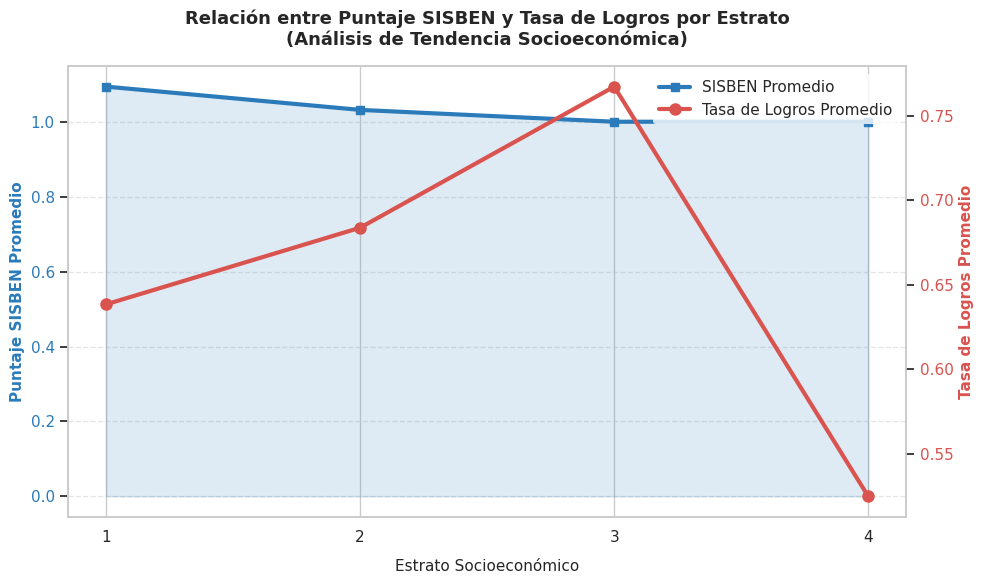

In [46]:
## Se grafica la relación entre estrato, puntaje SISBEN promedio y tasa de logros UNIDOS
df_est_pd = df_estrato_sisben.toPandas().sort_values("ESTRATO")

fig, ax1 = plt.subplots(figsize=(10, 6))
color_sisben, color_logros = "#2b7bba", "#d9534f"

ax1.plot(df_est_pd["ESTRATO"], df_est_pd["sisben_promedio"],
         color=color_sisben, linewidth=3, marker="s", label="SISBEN Promedio")
ax1.fill_between(df_est_pd["ESTRATO"], df_est_pd["sisben_promedio"], 
                 color=color_sisben, alpha=0.15)

ax1.set_xlabel("Estrato Socioeconómico", fontsize=11, labelpad=10)
ax1.set_ylabel("Puntaje SISBEN Promedio", color=color_sisben, fontsize=11, fontweight='bold')
ax1.tick_params(axis='y', labelcolor=color_sisben)
ax1.grid(True, axis='y', linestyle='--', alpha=0.5) 

ax2 = ax1.twinx()
ax2.plot(df_est_pd["ESTRATO"], df_est_pd["tasa_logros_promedio"],
         color=color_logros, linewidth=3, marker="o", markersize=8, label="Tasa de Logros Promedio")

ax2.set_ylabel("Tasa de Logros Promedio", color=color_logros, fontsize=11, fontweight='bold')
ax2.tick_params(axis='y', labelcolor=color_logros)
ax2.grid(False)

ax1.set_xticks(df_est_pd["ESTRATO"])

ax1.set_title("Relación entre Puntaje SISBEN y Tasa de Logros por Estrato\n(Análisis de Tendencia Socioeconómica)", 
             fontsize=13, fontweight='bold', pad=15)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right", frameon=True, facecolor='white', edgecolor='none')

plt.tight_layout()
plt.show()

Dentro de los 10 municipios, la relación positiva entre estrato y puntaje SISBEN confirma que el estrato es uno de los factores socioeconómicos con mayor incidencia sobre la vulnerabilidad medida. Sin embargo, en municipios como Quibdó y Bojayá casi todos los beneficiarios están en estrato 1, lo que significa que la dispersión del SISBEN en esos territorios responde a otros factores como el acceso a servicios básicos y las condiciones de vivienda, no tanto al estrato.

# Modelo LightGBM + SHAP — Predicción de Estrato

**Objetivo:** Entrenar un modelo de clasificación multiclase capaz de predecir el estrato socioeconómico (1–6) de un beneficiario, e identificar qué variables tienen mayor incidencia en la predicción. Con el fín de identificar las variables más incidentes en la pobreza de un individuo, para poder ofrecer un plan de mejora centrado en el desarrollo de esas variables

**Modelo seleccionado:** LightGBM + SHAP values
- LightGBM ofrece alto rendimiento con datasets de gran volumen y soporte nativo para variables categóricas.
- SHAP permite entender el impacto de cada variable sobre las predicciones de forma global y por clase.


In [47]:
### Se exporta el Pipeline de limpieza realizado anteriormente
dfPy04.write.mode("overwrite").parquet("../data/pobreza_limpio.parquet")
print("✓ Exportación completada")

✓ Exportación completada


In [48]:
## Librerias del modelo
import pandas as pd
import numpy as np
import lightgbm as lgb
import shap
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, f1_score

import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

print(f"LightGBM  : {lgb.__version__}")
print(f"SHAP      : {shap.__version__}")

LightGBM  : 4.6.0
SHAP      : 0.49.1


/home/estudiante/.local/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [75]:
## Carga de los datos de parquet
df = pd.read_parquet("../data/pobreza_limpio.parquet", engine='fastparquet')

print(f"Shape : {df.shape}")
print(f"\nDistribución de ESTRATO:")
print(df['ESTRATO'].value_counts().sort_index())

Shape : (222322, 73)

Distribución de ESTRATO:
ESTRATO
1    202752
2     18853
3       624
4        55
5        23
6        15
Name: count, dtype: int64


## Preparación de features

### Columnas a eliminar

Se descartan columnas que no deben entrar al modelo por las siguientes razones:

| Columna | Razón de exclusión |
|---|---|
| `ID_FAMILIA`, `COD_DEP`, `COD_MUN` | Identificadores sin valor predictivo |
| `estrato_norm` | Derivada del target → **data leakage** |
| `sisben_norm`, `log_puntaje_sisben` | Transformaciones redundantes de `PUNTAJE_SISBEN`; LightGBM no requiere normalización |
| `features`, `features_km`, `*_idx`, `*_ohe` | Artefactos del pipeline Spark ML |
| `tasa_logros` | Ponderado de todas las tasas, incluirlo sesgara los resultados, pues el modelo le dara gran importancia al capturar el movimiento de todas las tasas individuales |


In [76]:
## Se eliminan las columnas
COLS_DROP = [
    # Identificadores
    'ID_FAMILIA', 'COD_DEP', 'COD_MUN',
    # Derivada del target → leakage
    'estrato_norm',
    # Transformaciones redundantes de PUNTAJE_SISBEN
    'sisben_norm', 'log_puntaje_sisben',
    # Artefactos del pipeline Spark ML
    'features', 'features_km',
    'RANGO_EDAD_idx', 'GENERO_idx', 'PARENTESCO_idx',
    'RANGO_EDAD_ohe', 'GENERO_ohe', 'PARENTESCO_ohe'
]

# Eliminar solo las que existen en el DataFrame
cols_a_drop = [c for c in COLS_DROP if c in df.columns]
df = df.drop(columns=cols_a_drop)

print(f"Columnas eliminadas : {len(cols_a_drop)}")
print(f"Columnas restantes  : {df.shape[1]}")

Columnas eliminadas : 6
Columnas restantes  : 67


In [77]:
## Se separa la variable objetivo del resto
TARGET = 'ESTRATO'
y_raw  = df[TARGET].copy()
X      = df.drop(columns=[TARGET])

In [78]:
## Se convierten variables booleanas a enteras para correcta lectura
bool_cols = X.select_dtypes(include='bool').columns.tolist()
X[bool_cols] = X[bool_cols].astype('Int8')

print(f"Columnas booleanas convertidas : {len(bool_cols)}")
print(bool_cols)

Columnas booleanas convertidas : 25
['DISCAPACIDAD', 'PE34', 'PE35', 'PE36', 'PE37', 'PE38', 'PE39', 'PE40', 'PE41', 'PE43', 'PE44', 'PE45', 'PE46', 'PE48', 'PE50', 'PE51', 'HE11', 'HE12', 'HE13', 'HE14', 'HE15', 'HE16', 'HE21', 'HE22', 'HE23']


In [79]:
## Definición de variables categoricas como tipo 'category', permite a LightGBM encontrar las particiones de clases más eficiente que con un simple One Hot encoding
# Detectar automáticamente todas las columnas de tipo object o string
CAT_COLS = X.select_dtypes(include=['object', 'string']).columns.tolist()

for c in CAT_COLS:
    X[c] = X[c].astype('category')

print(f"Features categóricas detectadas : {len(CAT_COLS)}")
print(CAT_COLS)

print(f"Features categóricas : {len(CAT_COLS)}")
print(f"Features totales     : {X.shape[1]}")

Features categóricas detectadas : 11
['TIPO_DOC', 'RANGO_EDAD', 'NOM_DEP', 'NOM_MUN', 'ESTADO_CIVIL', 'GENERO', 'PARENTESCO', 'TIPO_POBLACION', 'ESTADO_BENEF', 'PE42', 'HE20']
Features categóricas : 11
Features totales     : 66


In [80]:
## Eliminación de ESTADO_CIVIL 
X = X.drop(columns=['ESTADO_CIVIL'], errors='ignore')

## Eliminación de tasa_logros 
X = X.drop(columns=['tasa_logros'], errors='ignore')

In [81]:
## Mostrar las variables y sus tipos de datos
pd.set_option('display.max_rows', None) # Desactivar limite a mostrar
print(X.dtypes) # Mostrar las variables

TIPO_DOC          category
RANGO_EDAD        category
NOM_DEP           category
NOM_MUN           category
PUNTAJE_SISBEN       int32
DISCAPACIDAD          Int8
GENERO            category
PARENTESCO        category
TIPO_POBLACION    category
ESTADO_BENEF      category
Logro1               int32
Logro2               int32
Logro3               int32
Logro4               int32
Logro5               int32
Logro6               int32
Logro7               int32
Logro8               int32
Logro9               int32
Logro10              int32
Logro11              int32
Logro12              int32
Logro13              int32
Logro14              int32
Logro15              int32
Logro16              int32
Logro17              int32
Logro18              int32
Logro19              int32
Logro20              int32
Logro21              int32
Logro22              int32
Logro23              int32
Logro24              int32
Logro25              int32
Logro26              int32
PE34                  Int8
P

In [82]:
## Se codifica la variable objetivo usando LabelEncoder [0,5] para el estrato
# Filtrar registros con ESTRATO nulo
mask_valido = y_raw.notna()
X     = X.loc[mask_valido].reset_index(drop=True)
y_raw = y_raw.loc[mask_valido].reset_index(drop=True)

# Aplicación de LabelEncoder a la variable objetivo
le = LabelEncoder()
y  = le.fit_transform(y_raw)

print(f"Clases detectadas : {le.classes_}")
print(f"Registros finales : {len(y):,}")

Clases detectadas : [1 2 3 4 5 6]
Registros finales : 222,322


In [83]:
## División por train/test donde el 80% de los datos se destinan a train y el 20% a test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y # Para asegurar igualdad de proporción de estrato en ambos conjuntos
)

print(f"Train : {X_train.shape[0]:,} registros")
print(f"Test  : {X_test.shape[0]:,} registros")
print(f"\nDistribución de clases en train:")
for cls, cnt in zip(*np.unique(y_train, return_counts=True)):
    print(f"  Estrato {le.classes_[cls]} → {cnt:,} ({cnt/len(y_train)*100:.1f}%)")

Train : 177,857 registros
Test  : 44,465 registros

Distribución de clases en train:
  Estrato 1 → 162,201 (91.2%)
  Estrato 2 → 15,082 (8.5%)
  Estrato 3 → 499 (0.3%)
  Estrato 4 → 44 (0.0%)
  Estrato 5 → 19 (0.0%)
  Estrato 6 → 12 (0.0%)


## **Modelado supervisado — LightGBM**

**LightGBM** es una librería de gradient boosting que construye ensambles de árboles de decisión de forma eficiente y con gran rendimiento, con API nativa de Python y compatibilidad tipo scikit‑learn (`LGBMClassifier`, `LGBMRegressor`).

## Supuestos básicos

- Es un método supervisado: requiere un conjunto de entrenamiento con etiquetas (regresión, clasificación binaria o multiclase).
- Opera sobre datos tabulares y maneja variables numéricas y categóricas (a través de `categorical_feature`).
- Asume que las características contienen señal predictiva suficiente para aprender mediante árboles de decisión y boosting iterativo.

## Hiperparámetros clave

Algunos hiperparámetros importantes (nombres pueden variar ligeramente según la API):

- `objective`: función de pérdida (por ejemplo, `"regression"`, `"binary"`, `"multiclass"`).  
- `metric`: métrica de evaluación (por ejemplo, `"rmse"`, `"binary_logloss"`, `"auc"`).  
- `num_iterations` / `num_boost_round`: número de iteraciones (número de árboles).  
- `learning_rate`: tasa de aprendizaje del boosting.  
- `num_leaves`: máximo número de hojas por árbol (controla la complejidad).  
- `max_depth`: profundidad máxima del árbol.  
- `min_data_in_leaf` y `min_gain_to_split`: controlan cuándo se realizan nuevas divisiones.  
- `feature_fraction`, `bagging_fraction`, `bagging_freq`: submuestreo por características y por filas.  
- `lambda_l1`, `lambda_l2`: regularización L1/L2.  
- `early_stopping_round`: parada temprana basada en el conjunto de validación.[web:6]

## Casos de uso típicos

- Modelado supervisado en **datos tabulares** con muchas filas y columnas (pricing, scoring de riesgo, churn, click‑through rate, etc.).
- Situaciones donde se requiere alta velocidad de entrenamiento e inferencia manteniendo gran precisión frente a otros métodos de gradient boosting.  

## Documentación oficial

- Documentación Python API: https://lightgbm.readthedocs.io/en/latest/Python-API.html 
- Página principal del proyecto: https://lightgbm.readthedocs.io/ 


### Hiperarámetros clave usados

| Parámetro | Valor | Justificación |
|---|---|---|
| `objective` | `multiclass` | Problema de clasificación con 6 clases |
| `num_leaves` | `63` | Controla la complejidad del árbol; buen punto de partida |
| `is_unbalance` | `True` | Ajusta los pesos de clase automáticamente para compensar la concentración en estrato 1 |
| `subsample` | `0.8` | Usa el 80% de los datos por árbol (bagging), reduce overfitting |
| `colsample_bytree` | `0.8` | Usa el 80% de las features por árbol, reduce overfitting |
| `early_stopping` | `50 rondas` | Detiene el entrenamiento si el loss en validación no mejora, evita overfitting |
| `n_jobs` | `-1` | Usa todos los núcleos de CPU disponibles |

In [90]:
## Entrenamiento del modelo

# Definición de hiperparametros
params = {
    'objective'         : 'multiclass',
    'num_class'         : len(le.classes_),
    'metric'            : 'multi_logloss',
    'n_estimators'      : 5000,
    'learning_rate'     : 0.05,
    'num_leaves'        : 63,
    'max_depth'         : -1,
    'min_child_samples' : 50,
    'subsample'         : 0.8,
    'colsample_bytree'  : 0.8,
    'is_unbalance'      : True,
    'n_jobs'            : -1,
    'random_state'      : 42,
    'verbose'           : -1,
}

model = lgb.LGBMClassifier(**params)

model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    callbacks=[
        lgb.early_stopping(stopping_rounds=50, verbose=True),
        lgb.log_evaluation(period=50)
    ]
)

print(f"\n✓ Entrenamiento completo — Iteraciones óptimas: {model.best_iteration_}")

Training until validation scores don't improve for 50 rounds
[50]	valid_0's multi_logloss: 0.208915
[100]	valid_0's multi_logloss: 0.195899
[150]	valid_0's multi_logloss: 0.192252
[200]	valid_0's multi_logloss: 0.186134
[250]	valid_0's multi_logloss: 0.182751
[300]	valid_0's multi_logloss: 0.179392
[350]	valid_0's multi_logloss: 0.187146
Early stopping, best iteration is:
[314]	valid_0's multi_logloss: 0.178707

✓ Entrenamiento completo — Iteraciones óptimas: 314


---
## Evaluación del modelo

Se evalúa el modelo sobre el conjunto de test con tres métricas:
- **Reporte de clasificación**: precisión, recall y F1 por cada estrato
- **F1-Macro**: promedio sin ponderar entre clases; penaliza el mal desempeño en estratos minoritarios
- **Matriz de confusión**: muestra dónde el modelo confunde un estrato con otro

In [91]:
y_pred = model.predict(X_test)

# Revertir la codificación para un reporte legible
y_test_lbl  = le.inverse_transform(y_test)
y_pred_lbl  = le.inverse_transform(y_pred)
class_names = [f"Estrato {c}" for c in le.classes_]

print("Reporte de Clasificación:")
print(classification_report(y_test_lbl, y_pred_lbl, target_names=class_names))

f1_macro    = f1_score(y_test, y_pred, average='macro')
f1_weighted = f1_score(y_test, y_pred, average='weighted')
print(f"F1-Macro    : {f1_macro:.4f}")
print(f"F1-Weighted : {f1_weighted:.4f}")

Reporte de Clasificación:
              precision    recall  f1-score   support

   Estrato 1       0.95      0.99      0.97     40551
   Estrato 2       0.74      0.41      0.53      3771
   Estrato 3       1.00      0.51      0.68       125
   Estrato 4       1.00      0.64      0.78        11
   Estrato 5       0.00      0.00      0.00         4
   Estrato 6       0.12      1.00      0.22         3

    accuracy                           0.94     44465
   macro avg       0.64      0.59      0.53     44465
weighted avg       0.93      0.94      0.93     44465

F1-Macro    : 0.5283
F1-Weighted : 0.9277


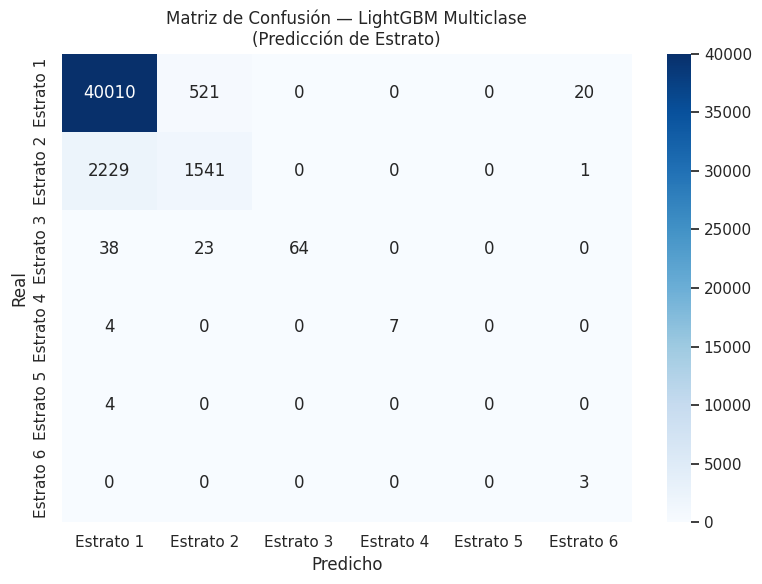

In [92]:
# Matriz de confusión
cm = confusion_matrix(y_test_lbl, y_pred_lbl, labels=le.classes_)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names,
    ax=ax
)
ax.set_xlabel('Predicho')
ax.set_ylabel('Real')
ax.set_title('Matriz de Confusión — LightGBM Multiclase\n(Predicción de Estrato)')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

## Hallazgos — Matriz de Confusión y Reporte de Clasificación

### Desempeño general

El modelo alcanza una **accuracy del 94%** y un **F1-Weighted de 0.93**, cifras
que a primera vista parecen excelentes. Sin embargo, estos valores están inflados
por el **desbalance extremo del dataset**: el 91.2% de los registros del set de
prueba pertenecen al Estrato 1 (40.551 de 44.465), por lo que un modelo que
predijera siempre Estrato 1 también tendría una accuracy alta. El **F1-Macro
de 0.53** es la métrica más honesta, ya que pondera igual todas las clases sin
importar su tamaño.

---

### Análisis por estrato

**Estrato 1 — Excelente desempeño (F1 = 0.97)**
El modelo identifica casi perfectamente los beneficiarios de estrato 1.
Solo 541 registros fueron clasificados en otro estrato, lo que representa
un error del 1.3%. Al ser la clase dominante, el modelo tiene abundante
información para aprenderla.

**Estrato 2 — Desempeño limitado con fuga hacia Estrato 1 (F1 = 0.53)**
De los 3.771 registros reales de Estrato 2, **2.229 fueron clasificados como
Estrato 1** (recall = 0.41). Este es el error más relevante del modelo en
términos absolutos e indica que las características de muchos beneficiarios
de Estrato 2 son muy similares a las del Estrato 1, dificultando la separación
entre ambas clases.

**Estrato 3 — Precisión perfecta pero bajo recall (F1 = 0.68)**
Cuando el modelo predice Estrato 3, acierta el 100% de las veces. Sin embargo,
solo recupera el 51% de los casos reales: 61 de 125 registros fueron asignados
a Estrato 1 o 2. La precisión perfecta sugiere que los casos que el modelo sí
detecta como Estrato 3 tienen características muy claras y diferenciadas del
resto.

**Estrato 4 — Buen desempeño relativo (F1 = 0.78)**
Con precisión del 100% y recall del 64%, el modelo acierta 7 de 11 registros
reales sin generar ningún falso positivo. La muestra es demasiado pequeña para
extraer conclusiones generalizables, pero la precisión perfecta indica que
los casos predichos como Estrato 4 tienen patrones muy distintivos.

**Estrato 5 — Sin predicciones (F1 = 0.00)**
Los 4 registros reales de Estrato 5 fueron clasificados todos como Estrato 1.
Con tan pocos casos en el set de prueba, el modelo no tiene suficiente
información para aprender este estrato. Resultado sin validez estadística.

**Estrato 6 — Comportamiento atípico (F1 = 0.22)**
El modelo predice Estrato 6 en exceso: clasifica 20 registros del Estrato 1
real como Estrato 6, mientras que los 3 registros reales de Estrato 6 sí los
acierta (recall = 1.00). Esto genera una precisión muy baja (0.12) e indica
que algunos patrones de los logros individuales del Estrato 1 se confunden
con los del Estrato 6.

---

### Patrón de error dominante

La mayoría de errores siguen una dirección consistente: **clasificar un estrato
superior como Estrato 1**, la clase dominante. La excepción es el Estrato 6,
donde el modelo sobreprediece esta clase clasificando 20 registros reales de
Estrato 1 como Estrato 6, comportamiento que no se replica en ningún otro estrato.

---

### Conclusión

El modelo es **confiable para Estrato 1 y parcialmente útil para Estrato 2 y 3**.
Para los estratos 4 al 6, la cantidad de registros en el dataset es demasiado
baja para que el modelo aprenda sus patrones con solidez. 

# Uso de SHAP y LightGBM para valoración de variables

**SHAP (SHapley Additive exPlanations)** es un enfoque basado en teoría de juegos para explicar la salida de cualquier modelo de machine learning asignando contribuciones a cada característica.

## ¿Cómo funciona SHAP?

- Se basa en los **valores de Shapley**: mide la contribución marginal de cada feature sobre todas las coaliciones posibles de características.
- Implementa variantes eficientes como **TreeSHAP** para modelos de árboles en ensamble (XGBoost, LightGBM, CatBoost, etc.), permitiendo cálculo rápido y exacto de valores SHAP.
- La librería `shap` proporciona herramientas de visualización (plots de resumen, dependencia, waterfall, force plots) para entender globalmente y localmente el modelo.

## Uso con modelos LightGBM

Existen dos vías principales:

1. **Con la librería `shap`**  
   - Entrenas tu modelo `lightgbm` (`lgb.train` o `LGBMClassifier`/`LGBMRegressor`).
   - Creas un `shap.Explainer` o `shap.TreeExplainer(model)` y luego calculas `shap_values = explainer(X)`.  
   - Puedes generar gráficos como `shap.plots.beeswarm(shap_values)` o `shap.plots.waterfall(shap_values[i])` para inspeccionar contribuciones.

2. **Desde LightGBM directamente**  
   - La API de LightGBM permite `predict(X, pred_contrib=True)` para obtener valores tipo SHAP por feature y por instancia (incluyendo el término base).

## Casos de uso con LightGBM

- Explicar por qué un modelo LightGBM predice un cierto score para un cliente concreto (explicaciones locales).  
- Identificar las características más influyentes globalmente en el rendimiento del modelo, más allá de la simple importancia de características por ganancia o frecuencia.

## Documentación oficial

- Documentación SHAP: https://shap.readthedocs.io/en/latest/
- Ejemplo oficial “Census income classification with LightGBM” usando SHAP: https://shap.readthedocs.io/en/latest/example_notebooks/tabular_examples/tree_based_models/Census%20income%20classification%20with%20LightGBM.html

In [93]:
# Importancia nativa de LightGBM
# importance_type='gain'  → reducción promedio de impureza aportada por la variable
# importance_type='split' → número de veces que la variable fue usada para dividir

importancia_gain  = model.booster_.feature_importance(importance_type='gain')
importancia_split = model.booster_.feature_importance(importance_type='split')

df_lgbm_imp = (
    pd.DataFrame({
        'Variable' : X_train.columns,
        'Gain'     : importancia_gain,
        'Split'    : importancia_split
    })
    .sort_values('Gain', ascending=False)
    .reset_index(drop=True)
)

print("Top 20 variables — Importancia nativa LightGBM (Gain):")
print(df_lgbm_imp.head(20).to_string(index=False))

Top 20 variables — Importancia nativa LightGBM (Gain):
Variable         Gain  Split
    PE37 2.454751e+07     81
 Logro21 1.933013e+07   1900
 Logro15 1.435433e+07   2417
    HE17 1.356326e+07  14130
    HE12 1.104237e+07   1499
 Logro26 7.626092e+06   4023
 Logro22 5.415041e+06   2464
 Logro20 5.346768e+06   2112
    PE44 5.274895e+06   1504
 Logro24 5.205603e+06   3214
 Logro10 4.606344e+06   2299
    HE18 4.439791e+06   6944
 Logro25 4.360466e+06   2468
 Logro16 4.348939e+06   3272
 Logro23 3.984080e+06   2097
 Logro19 3.914350e+06   2166
    HE14 3.446642e+06   3336
  Logro9 3.419677e+06   2261
    HE20 3.111799e+06    907
    PE39 2.934998e+06   1571


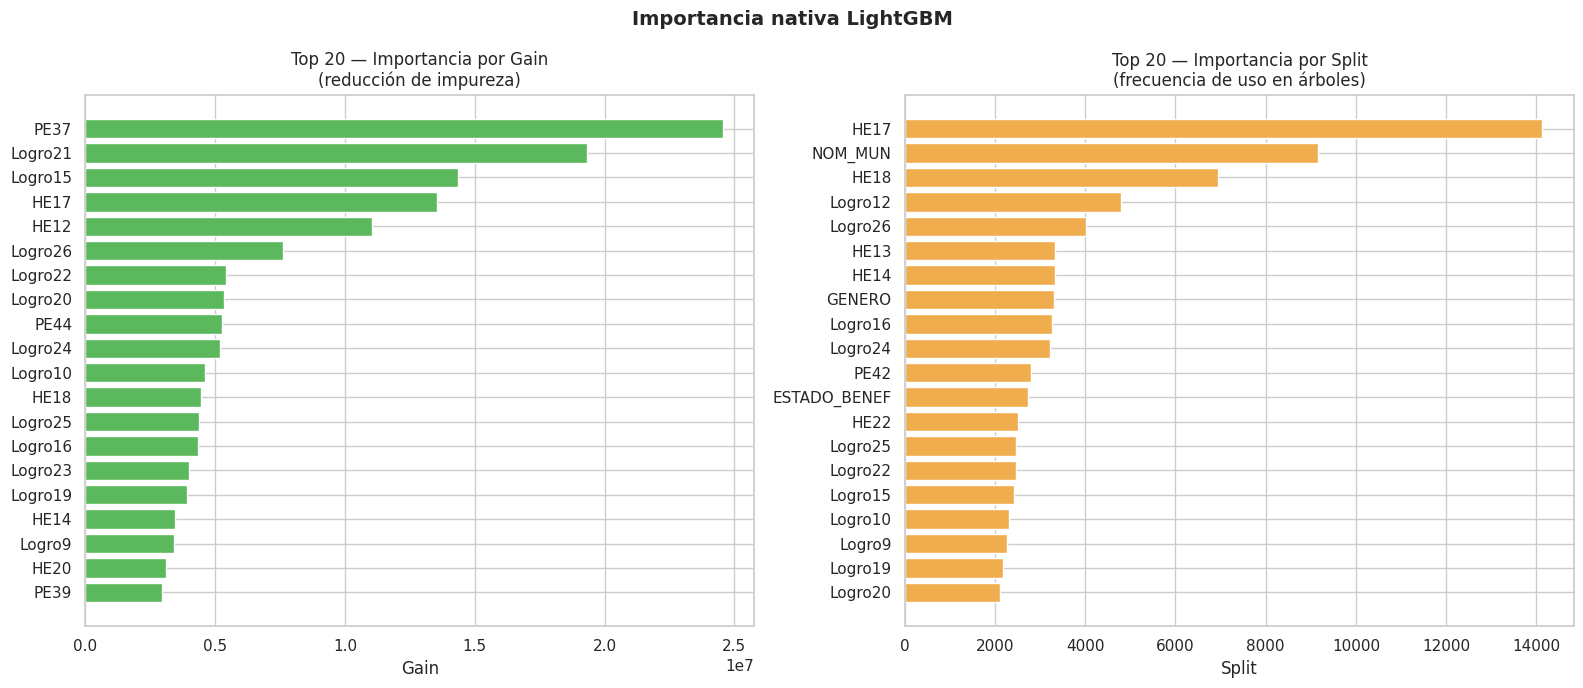

In [94]:
## Grafico de importancia nativa de LightGBM
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
top20_lgbm = df_lgbm_imp.head(20)

# Gain
axes[0].barh(top20_lgbm['Variable'][::-1], top20_lgbm['Gain'][::-1],
             color='#5cb85c', edgecolor='white')
axes[0].set_xlabel('Gain')
axes[0].set_title('Top 20 — Importancia por Gain\n(reducción de impureza)')

# Split
top20_split = df_lgbm_imp.sort_values('Split', ascending=False).head(20)
axes[1].barh(top20_split['Variable'][::-1], top20_split['Split'][::-1],
             color='#f0ad4e', edgecolor='white')
axes[1].set_xlabel('Split')
axes[1].set_title('Top 20 — Importancia por Split\n(frecuencia de uso en árboles)')

plt.suptitle('Importancia nativa LightGBM', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('lgbm_importancia_nativa.png', dpi=150)
plt.show()

In [95]:
## Uso de SHAP
N_SHAP = __builtins__.min(100_000, len(X_test))
X_shap = X_test.sample(N_SHAP, random_state=42)

print(f"Calculando SHAP values sobre {N_SHAP:,} registros...")

# tree_path_dependent es necesario cuando el modelo tiene variables categóricas nativas
explainer   = shap.TreeExplainer(model, feature_perturbation="tree_path_dependent")
shap_values = explainer.shap_values(X_shap)
# shap_values → lista de arrays, uno por clase [n_muestras × n_features]

print(f"✓ SHAP values calculados — {len(shap_values)} arrays (uno por clase)")

Calculando SHAP values sobre 44,465 registros...
✓ SHAP values calculados — 44465 arrays (uno por clase)


In [96]:
# shap_values shape: (n_muestras, n_features, n_clases) → (N_SHAP, 65, 6)
# Promedio sobre muestras (axis=0) y clases (axis=2) → shape (65,) = una por feature
importancia_shap = np.abs(shap_values).mean(axis=(0, 2))

df_shap_imp = (
    pd.DataFrame({        'Variable'   : X_shap.columns,
        'Importancia': importancia_shap
    })
    .sort_values('Importancia', ascending=False)
    .reset_index(drop=True)
)

print("Top 20 variables — Importancia SHAP global:")
print(df_shap_imp.head(20).to_string(index=False))

Top 20 variables — Importancia SHAP global:
Variable  Importancia
    HE17    46.763557
    PE40    38.047152
 Logro15    22.042011
 Logro26    17.802670
    HE18    13.225871
 Logro22    12.735553
    HE14    11.021976
  Logro9     9.097848
 Logro20     8.674251
    HE21     8.309287
 Logro16     8.194776
 Logro24     8.101892
 Logro12     7.927146
 Logro19     7.255354
    HE15     6.740551
    PE44     6.554357
    HE12     6.508824
    HE16     6.093426
 Logro21     5.271693
  Logro7     4.946496


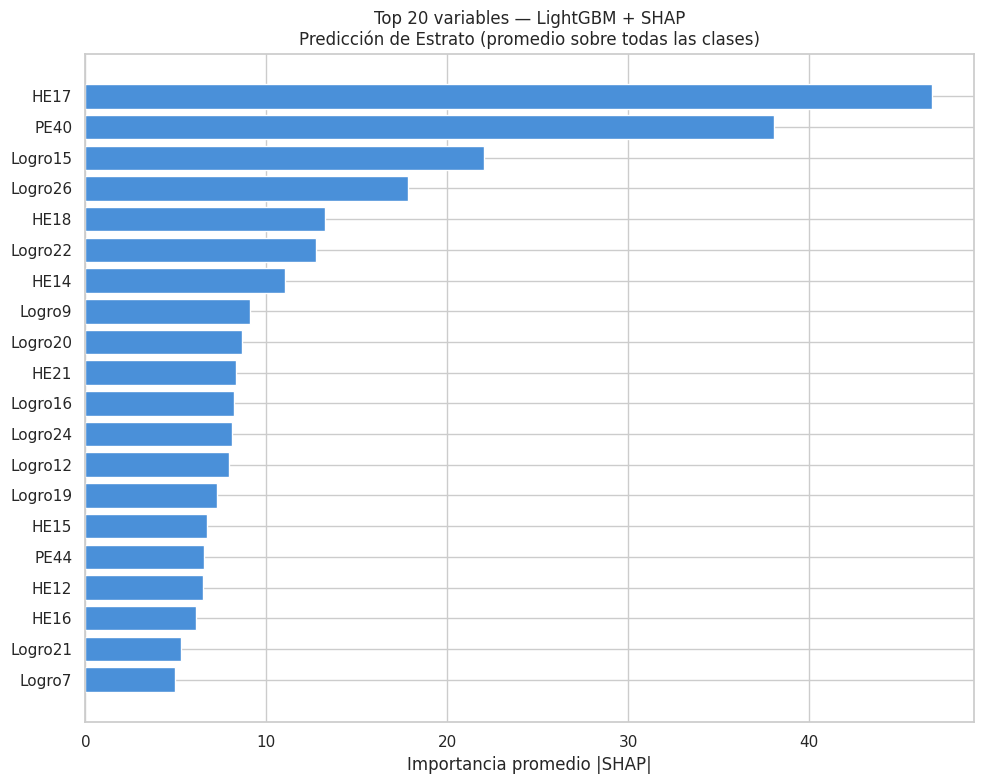

In [97]:
# Gráfico de barras — importancia global
top20 = df_shap_imp.head(20)

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(top20['Variable'][::-1], top20['Importancia'][::-1],
        color='#4a90d9', edgecolor='white')
ax.set_xlabel('Importancia promedio |SHAP|')
ax.set_title(
    'Top 20 variables — LightGBM + SHAP\n'
    'Predicción de Estrato (promedio sobre todas las clases)'
)
plt.tight_layout()
plt.savefig('shap_importancia_global.png', dpi=150)
plt.show()

## Hallazgos — Importancia de variables (LightGBM nativo + SHAP)

### Variables más determinantes

El análisis combina tres métricas de importancia: **Gain** (reducción de impureza
en los árboles), **Split** (frecuencia de uso para dividir nodos) y **SHAP**
(contribución marginal real sobre cada predicción). Las variables con mayor
solidez son aquellas que aparecen destacadas en más de un método.

---

### HE17 — Número de personas en el hogar
**Tipo:** Entero continuo | **Posición:** #1 SHAP, top 4 Gain, #1 Split

Es la variable más importante del modelo según SHAP y la más frecuentemente
usada por LightGBM para construir sus árboles. El número de personas en el
hogar es un indicador directo de hacinamiento: a mayor cantidad de personas
en el mismo espacio, mayor presión sobre los recursos del hogar y menor
probabilidad de pertenecer a un estrato alto. Su naturaleza continua le permite
al modelo construir particiones muy precisas y discriminantes entre estratos.

---

### HE18 — Número de cuartos en el hogar
**Tipo:** Entero continuo | **Posición:** top 5 SHAP, top 3 Split, aparece en Gain

Complementa directamente a HE17. Combinadas, estas dos variables permiten
al modelo estimar el índice de hacinamiento del hogar (personas por cuarto),
que en Colombia es uno de los criterios técnicos que incide en la clasificación
del estrato. Un hogar con muchas personas y pocos cuartos tiene un perfil
consistente con estratos bajos; la relación inversa aplica para estratos altos.

---

### PE40 — Sabe leer y escribir
**Tipo:** Binario (1 = sí, 0 = no) | **Posición:** #2 SHAP

Es la segunda variable más importante según SHAP pero no aparece en el top 20
de LightGBM nativo, lo que indica que su impacto es real sobre las predicciones
individuales pero no se manifiesta en la frecuencia o ganancia de los árboles.
La alfabetización está fuertemente correlacionada con el nivel socioeconómico:
los hogares con adultos que no saben leer ni escribir tienen una probabilidad
marcadamente mayor de pertenecer al estrato 1. SHAP la detecta como el segundo
factor más influyente porque su valor binario genera una separación clara
entre perfiles de vulnerabilidad.

---

### Logro15 — Seguridad Alimentaria
**Tipo:** Ternario (1 = alcanzado, 0 = por alcanzar, −1 = no aplica) | **Posición:** #3 SHAP, aparece en Gain

La seguridad alimentaria mide si el hogar garantiza acceso suficiente y estable
a alimentos. Es una de las necesidades más básicas de la pirámide de vulnerabilidad
y su estado (alcanzado vs. por alcanzar) discrimina fuertemente entre estratos:
los hogares de estrato 1 concentran la mayor proporción de este logro pendiente.
Su alta posición en SHAP confirma que no haberlo alcanzado es una señal potente
de pertenencia al estrato más bajo.

---

### Logro26 — Seguridad Jurídica del Predio
**Tipo:** Ternario | **Posición:** #4 SHAP, top 5 Split, aparece en Gain

Mide si el hogar tiene la situación legal de su terreno o vivienda regularizada.
En Colombia, la tenencia informal del suelo está altamente concentrada en estratos
1 y 2, mientras que los estratos superiores tienden a tener escrituras y títulos
formalizados. Esta variable conecta directamente con HE14 (escritura registrada)
y juntas forman el núcleo del perfil de seguridad jurídica del hogar.

---

### HE14 — Escritura registrada de la vivienda
**Tipo:** Binario (1 = sí, 0 = no) | **Posición:** top 7 SHAP, aparece en Gain y Split

Indica si algún integrante del hogar posee escritura registrada. Tener escritura
es un marcador de formalización patrimonial que diferencia los estratos bajos
(donde predomina la tenencia informal) de los estratos medios y altos. Su
alineación con Logro26 refuerza que la dimensión jurídico-patrimonial del hogar
es uno de los ejes explicativos más fuertes del estrato.

---

### Logro22 — Paredes
**Tipo:** Ternario | **Posición:** top 6 SHAP, aparece en Gain y Split

Mide si las paredes del hogar cumplen condiciones mínimas de habitabilidad.
El material de las paredes es uno de los criterios técnicos directos que usa
el DANE para determinar el estrato en Colombia, lo que explica su alta importancia:
el modelo está aprendiendo una de las reglas reales de estratificación. Un hogar
con paredes en condición precaria tiene un perfil consistente con estrato 1,
mientras que paredes de material sólido apuntan a estratos superiores.

---

### Logro9 — Acceso a Agua
**Tipo:** Ternario | **Posición:** top 8 SHAP

El acceso a agua potable es un servicio público básico cuya cobertura varía
sistemáticamente con el estrato. En Colombia, los estratos bajos concentran
la mayor proporción de hogares sin acceso a acueducto formal. Un logro pendiente
en esta dimensión es una señal directa de estrato 1, mientras que su cumplimiento
no distingue de forma tan clara los estratos medios y altos entre sí.

---

### Logro20 — Educación Financiera
**Tipo:** Ternario | **Posición:** top 9 SHAP

Mide si los adultos del hogar han accedido a formación en educación financiera.
Su importancia en el modelo refleja que el acceso a este tipo de conocimiento
está estratificado: los hogares de estratos más altos tienen mayor probabilidad
de haber alcanzado este logro, bien por acceso a programas formales o por
mayor nivel educativo general de sus integrantes.

---

### NOM_MUN — Municipio de atención
**Tipo:** Categórico | **Posición:** #2 Split, no aparece en SHAP

Es la segunda variable más usada para dividir nodos en los árboles de LightGBM,
lo que indica que el municipio es un criterio frecuente de segmentación. Sin
embargo, su baja posición en SHAP sugiere que aunque el modelo la usa mucho,
su contribución marginal real sobre cada predicción individual es menor que
la de las variables de condición del hogar. Esto tiene sentido: el municipio
es un proxy del contexto territorial, pero lo que determina el estrato son
las condiciones específicas del hogar dentro de ese municipio.

---

### Síntesis

Las variables más determinantes para predecir el estrato se agrupan en tres
dimensiones:

| Dimensión | Variables | Interpretación |
|---|---|---|
| **Condiciones físicas del hogar** | HE17, HE18, Logro22 (Paredes) | Hacinamiento y calidad de la vivienda; criterios directos de estratificación en Colombia |
| **Seguridad patrimonial y jurídica** | Logro26, HE14 | Formalización de la tenencia del suelo; marcador de estratos medios y altos |
| **Acceso a necesidades básicas** | Logro15, Logro9, PE40 | Seguridad alimentaria, agua y alfabetización; concentrados en estrato 1 |

Esta estructura coincide con los criterios técnicos reales de estratificación
del DANE, lo que valida que el modelo está capturando los factores correctos
y que sus predicciones tienen respaldo en la realidad socioeconómica del país.

### 8.2 Summary Plot

El summary plot muestra dos cosas simultáneamente:
- **Posición en X**: si el valor SHAP es positivo, esa variable empuja la predicción hacia un estrato más alto; si es negativo, hacia uno más bajo.
- **Color**: rojo indica valores altos de la variable, azul indica valores bajos.

Por ejemplo, si `PUNTAJE_SISBEN` aparece con puntos rojos a la derecha, significa que puntajes SISBEN altos empujan hacia estratos más altos.

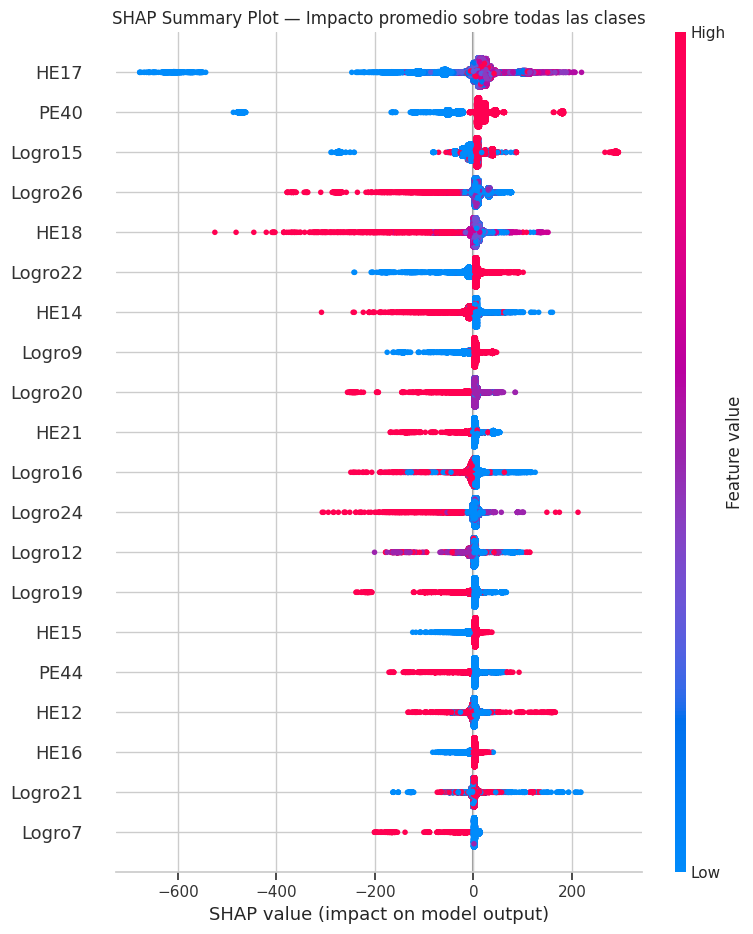

In [98]:
# shap_values[:, :, 0] → contribuciones para la clase 0 (Estrato 1)
shap_promedio = shap_values.mean(axis=2)  # Promedio sobre clases → (n_muestras, n_features)

plt.figure()
shap.summary_plot(shap_promedio, X_shap, max_display=20, show=False)
plt.title('SHAP Summary Plot — Impacto promedio sobre todas las clases')
plt.tight_layout()
plt.savefig('shap_summary_plot.png', dpi=150)
plt.show()

## Hallazgos — SHAP Summary Plot

### Cómo leer este gráfico

Cada fila es una variable y cada punto es un registro del set de prueba.
La posición en el eje X indica la dirección e intensidad del impacto de esa
variable sobre la predicción del estrato:

- **Puntos a la izquierda (SHAP negativo):** la variable empuja la predicción
  hacia estratos más bajos
- **Puntos a la derecha (SHAP positivo):** la variable empuja la predicción
  hacia estratos más altos
- **Color rojo:** el valor de la variable en ese registro es alto
- **Color azul:** el valor de la variable en ese registro es bajo
- **Dispersión horizontal:** a mayor dispersión, mayor variabilidad en el
  impacto de esa variable — las variables con nubes más anchas son más
  determinantes

---

### Análisis por variable

**HE17 — Número de personas en el hogar**
Es la variable con mayor dispersión de todo el gráfico (rango hasta −600).
Los puntos azules (pocos integrantes) se concentran en el extremo izquierdo,
lo que indica que los hogares con muy pocas personas reciben predicciones
fuertemente hacia estratos bajos. Esto puede parecer contraintuitivo, pero
refleja que en el contexto de la Estrategia UNIDOS, los hogares unipersonales
o muy pequeños suelen ser adultos mayores solos o personas en situación de
alta vulnerabilidad, que pertenecen mayoritariamente al estrato 1.

**PE40 — Sabe leer y escribir**
Los puntos azules (no sabe leer ni escribir) se dispersan marcadamente hacia
la izquierda (hasta −300), mientras que los rojos (sí sabe) se concentran
cerca de 0 o ligeramente positivos. El patrón es claro: la analfabetización
es una señal potente de estrato 1. Dado que esta variable es binaria,
la separación entre ambos grupos es muy limpia y explica por qué SHAP
la posiciona como la segunda variable más importante.

**Logro15 — Seguridad Alimentaria**
Los puntos rojos (logro alcanzado) se concentran a la derecha y los azules
(por alcanzar o no aplica) a la izquierda. Tener la seguridad alimentaria
garantizada empuja la predicción hacia estratos superiores; no tenerla
es una señal consistente de estrato 1. La dispersión es amplia, lo que
confirma que este logro discrimina bien entre clases.

**Logro26 — Seguridad Jurídica del Predio**
Los puntos azules (logro no alcanzado) se extienden muy lejos a la izquierda
(hasta −400), siendo el patrón más extremo entre las variables de logros.
La ausencia de seguridad jurídica sobre el predio es el predictor más potente
de estrato bajo dentro de los logros UNIDOS, lo que tiene coherencia directa
con la realidad colombiana: la tenencia informal del suelo está concentrada
en estratos 1 y 2.

**HE18 — Número de cuartos en el hogar**
Los puntos azules (pocos cuartos) se dispersan a la izquierda y los rojos
(muchos cuartos) a la derecha. El patrón es simétrico y continuo: a más
cuartos, mayor predicción de estrato alto. Combinada con HE17, el modelo
construye implícitamente un índice de hacinamiento que es altamente
discriminante entre estratos.

**Logro22 — Paredes**
Presenta puntos de ambos colores en ambas direcciones, pero con mayor
concentración cerca del centro. Esto indica que el estado de las paredes
tiene impacto pero es más variable según el contexto del hogar, posiblemente
porque interactúa con otras variables de vivienda como HE12 (pisos) y
HE16 (saneamiento).

**HE14 — Escritura registrada de la vivienda**
Los puntos azules (sin escritura) se desplazan a la izquierda y los rojos
(con escritura) a la derecha. El patrón complementa a Logro26: tener
escritura registrada y seguridad jurídica del predio actúan en la misma
dirección, confirmando que la formalización del patrimonio es un eje
diferenciador clave entre estratos.

**HE21 — Algún menor dejó de comer alguna comida del día**
Variable binaria con puntos rojos (sí ocurrió) desplazados a la izquierda.
La privación alimentaria de menores es una señal directa de vulnerabilidad
extrema y empuja la predicción hacia el estrato más bajo. Su posición en
el top 10 del gráfico la convierte en un indicador potente a pesar de ser
una sola pregunta binaria.

**HE15 — Vivienda con acueducto o pozo con bomba**
Los puntos rojos (sí tiene acceso a agua formal) se desplazan a la derecha,
mientras los azules (sin acceso) van a la izquierda. Tener acueducto público
o comunal es un marcador de integración a servicios formales que diferencia
los estratos bajos de los medios. Coincide en dirección con Logro9
(Acceso a Agua), reforzando esta dimensión.

**HE12 — Vivienda con pisos en tierra**
Los puntos rojos (sí tiene pisos en tierra) se concentran a la izquierda,
empujando fuertemente hacia estrato 1. El piso en tierra es uno de los
criterios físicos más directos que usa el DANE para clasificar viviendas
en estratos bajos. Su presencia es casi excluyente de estratos 2 en adelante,
lo que explica la separación clara entre colores en el gráfico.

**HE16 — Inodoro conectado a alcantarillado o pozo séptico**
Patrón similar a HE15: tener saneamiento básico (rojo) empuja hacia estratos
más altos. La ausencia de inodoro formal (azul) es una característica
asociada casi exclusivamente al estrato 1 en zonas urbanas y periurbanas.

**PE44 — Participó en cursos de educación financiera**
Los puntos rojos (sí participó) se desplazan levemente a la derecha.
El impacto es menor que PE40 (alfabetización), lo que tiene sentido: haber
tomado un curso de educación financiera es un indicador de acceso a
programas de capacitación, que está correlacionado con el estrato pero
de forma menos determinante que la alfabetización básica.

**Logro21 — Pisos**
El logro de condiciones mínimas en pisos del hogar (no tierra, no material
precario) actúa en la misma dirección que HE12 pero desde la perspectiva
del logro UNIDOS. Los puntos azules (logro no alcanzado) se extienden a
la izquierda. Es coherente que ambas variables aparezcan en el top 20:
miden la misma dimensión física desde dos instrumentos distintos
(encuesta de hogar vs. seguimiento UNIDOS).

**Logro24 — Ingreso Propio Adultos Mayores**
Los puntos azules (sin ingreso propio) se desplazan a la izquierda con
puntos que llegan hasta −400. Los adultos mayores sin ingreso propio son
un perfil de alta vulnerabilidad concentrado en estrato 1. La presencia
de ingresos propios en la tercera edad (pensión, renta) es un diferenciador
de estratos medios y altos.

**Logro7 — Acceso al Sistema Educativo**
Los puntos azules (logro no alcanzado) se dispersan a la izquierda. La
falta de acceso al sistema educativo formal es una característica estructural
de los hogares de estrato 1, especialmente en municipios alejados. Su
posición en el top 20 confirma que la dimensión educativa es transversal
a la predicción del estrato, complementando a PE40 (alfabetización).

---

### Síntesis del Summary Plot

El gráfico revela tres patrones estructurales:

**1. Variables con impacto asimétrico (una dirección dominante)**
HE12, PE40, HE21 y Logro26 muestran que sus valores bajos (azul)
generan impactos negativos extremos, mientras que los valores altos tienen
impacto moderado. Esto significa que la **ausencia** de condiciones básicas
es más informativa para predecir estrato bajo que la presencia para predecir
estrato alto.

**2. Variables con impacto simétrico (ambas direcciones)**
HE17, HE18 y Logro24 tienen puntos dispersos en ambas direcciones según
el color. Estas variables discriminan en ambos sentidos y son útiles tanto
para identificar estrato 1 como estratos superiores.

**3. Variables con impacto concentrado cerca del centro**
Logro12, Logro16 y Logro19 tienen dispersión más estrecha, indicando que
su impacto individual es menor aunque siguen siendo relevantes en conjunto.

En términos de política pública, los hallazgos del summary plot sugieren
que **mejorar las condiciones físicas del hogar** (pisos, paredes, agua,
saneamiento) y **garantizar la seguridad jurídica del predio** son las
intervenciones con mayor potencial de impacto sobre la estratificación,
dado que son las dimensiones donde la ausencia genera las señales más
extremas hacia el estrato más bajo.

### 8.3 Importancia SHAP por estrato

Muestra qué variables son más determinantes para identificar **cada estrato específicamente**.
Útil para entender si los factores que predicen el estrato 1 son los mismos que predicen el estrato 3 o 4.

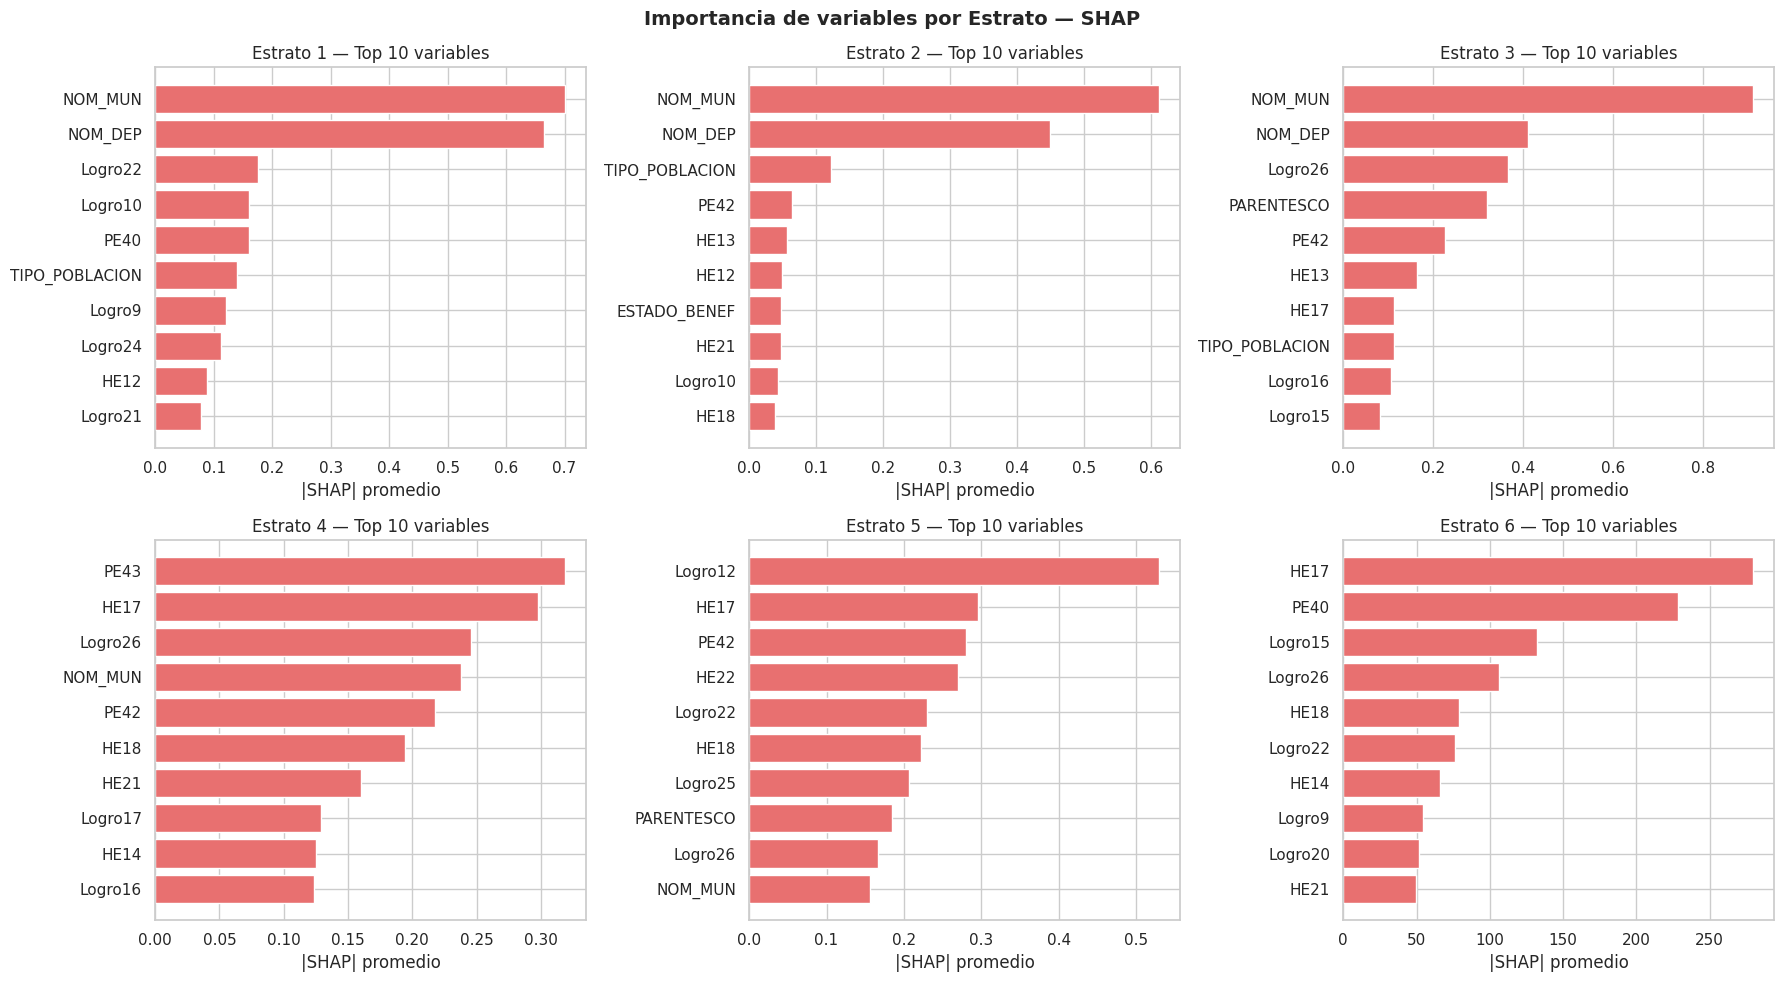

In [99]:
n_clases = len(le.classes_)
n_cols   = 3
n_rows   = int(np.ceil(n_clases / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 5))
axes = axes.flatten()

for i in range(n_clases):
    # shap_values[:, :, i] → todas las muestras, todas las features, clase i
    imp = (
        pd.Series(
            np.abs(shap_values[:, :, i]).mean(axis=0),
            index=X_shap.columns
        )
        .sort_values(ascending=False)
        .head(10)
    )
    axes[i].barh(imp.index[::-1], imp.values[::-1], color='#e87070', edgecolor='white')
    axes[i].set_title(f'Estrato {le.classes_[i]} — Top 10 variables')
    axes[i].set_xlabel('|SHAP| promedio')

# Ocultar subplots sobrantes si n_clases no es múltiplo de n_cols
for j in range(n_clases, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Importancia de variables por Estrato — SHAP', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_por_estrato.png', dpi=150)
plt.show()

## Hallazgos — Importancia de variables por Estrato (SHAP)

### Cómo leer este gráfico

Cada subgráfico muestra las 10 variables con mayor valor |SHAP| promedio
para predecir un estrato específico. A diferencia del summary plot global,
aquí el modelo responde: **¿qué variables son más determinantes para
identificar que un beneficiario pertenece a ESTE estrato en particular?**
Una variable que aparece en el top 10 de un estrato pero no en otro indica
que su poder discriminatorio es específico de ese nivel socioeconómico.

---

### Estrato 1 — Perfil territorial y condiciones básicas

**Variables dominantes:** `NOM_MUN` (~0.70), `NOM_DEP` (~0.65)

La ubicación geográfica domina completamente la predicción del estrato 1.
El municipio y departamento de atención concentran casi toda la importancia,
lo que refleja que la pobreza extrema en Colombia tiene una distribución
territorial muy marcada: municipios como Quibdó, Bojayá, Uribia y Mitú
concentran abrumadoramente beneficiarios de estrato 1. El modelo aprendió
este patrón geográfico como la señal más fuerte.

Tras la geografía aparecen `Logro22` (Paredes), `Logro10` (Saneamiento
Básico), `PE40` (Alfabetización), `Logro9` (Agua) y `HE12` (Pisos en
tierra), confirmando que las condiciones físicas de la vivienda y el
acceso a servicios básicos son los factores de segundo orden más
discriminantes para este estrato.

`TIPO_POBLACION` también aparece, indicando que el tipo de programa al
que pertenece el beneficiario (población desplazada, en pobreza extrema,
étnica, etc.) tiene valor predictivo para identificar el estrato más bajo.

---

### Estrato 2 — Transición entre geografía y condiciones del hogar

**Variables dominantes:** `NOM_MUN` (~0.60), `NOM_DEP` (~0.45)

La geografía sigue dominando pero con menor distancia respecto al resto
de variables que en el Estrato 1. Comienzan a emerger variables de
condición del hogar con mayor peso relativo: `HE13` (predio propio),
`HE12` (pisos en tierra), `HE21` (menor sin alimentación) y `HE18`
(cuartos). Esto indica que el modelo necesita más información específica
del hogar para distinguir el Estrato 2 del 1, ya que ambos comparten
perfiles geográficos similares.

`PE42` (último grado aprobado) aparece por primera vez, señalando que
el nivel educativo empieza a ser discriminante a partir del Estrato 2.
`ESTADO_BENEF` también emerge: el estado del beneficiario dentro del
programa (activo, atendido, retirado) tiene valor informativo para
separar este estrato del anterior.

---

### Estrato 3 — Dominio geográfico extremo

**Variables dominantes:** `NOM_MUN` (~0.85), `NOM_DEP` (~0.35)

El municipio alcanza su mayor importancia relativa en este estrato,
con un valor SHAP promedio de 0.85 que supera al de cualquier otra
variable en cualquier otro estrato. Esto indica que el Estrato 3 está
geográficamente muy concentrado: ciertos municipios predicen casi por
sí solos la pertenencia a este estrato, lo que sugiere que hay muy
pocos municipios dentro del dataset con beneficiarios de Estrato 3.

`PARENTESCO` emerge aquí como variable relevante: el rol del beneficiario
dentro del hogar (jefe de hogar, cónyuge, hijo) tiene valor predictivo
específico para este estrato. `Logro26` (Seguridad Jurídica del Predio)
también aparece, apuntando a que la formalización de la tenencia del
suelo comienza a ser un diferenciador a partir del Estrato 3.

---

### Estrato 4 — El trabajo como variable central

**Variables dominantes:** `PE43` (~0.32), `HE17` (~0.30)

Este estrato marca un quiebre estructural: la geografía cae al cuarto
lugar y el empleo toma el primer puesto. `PE43` (trabaja o tiene negocio
propio) es la variable más importante para identificar el Estrato 4,
lo que tiene coherencia directa con la realidad colombiana: a partir
del Estrato 4, la inserción laboral formal o el emprendimiento son
marcadores más diferenciadores que el territorio o las condiciones
básicas del hogar.

`HE17` (personas en el hogar) y `HE18` (cuartos) mantienen su relevancia,
pero ahora en el contexto de hogares más pequeños con más espacio, que
es el perfil típico de estratos medios. `Logro17` (Leer y Escribir como
logro formal) aparece aquí, complementando a `PE40`: no solo se trata
de saber leer sino de haber formalizado este logro dentro del programa.

---

### Estrato 5 — Perfil atípico (muestra insuficiente)

**Variables dominantes:** `Logro12` (~0.55), `HE17` (~0.30)

Con solo 4 registros reales en el set de prueba, los resultados de este
estrato no tienen validez estadística y deben interpretarse con cautela.
La dominancia de `Logro12` (Libreta Militar) en primer lugar es
probablemente un artefacto de la muestra pequeña: al ser un logro
que aplica exclusivamente a hombres en cierto rango de edad, su presencia
en pocos registros específicos puede haber generado un peso desproporcionado.

`HE22` (hogar sin alimentos) y `Logro25` (Vinculación a Actividad
Productiva) aparecen aquí, lo que podría indicar perfiles de vulnerabilidad
específicos, pero sin suficiente muestra no es posible generalizar.

---

### Estrato 6 — Condiciones individuales sobre geografía

**Variables dominantes:** `HE17` (~270), `PE40` (~240)

El Estrato 6 presenta el cambio más radical: la geografía desaparece
completamente del top 10 y las condiciones individuales del hogar
dominan con valores SHAP de escala muy superior al resto de estratos.
`HE17` y `PE40` lideran con distancia, seguidos de `Logro15`, `Logro26`,
`HE18`, `Logro22` y `HE14`. El perfil de un hogar de Estrato 6 en este
dataset se define por características muy específicas del hogar, no por
su ubicación geográfica.

Cabe resaltar que con solo 3 registros reales de Estrato 6 en el set
de prueba, estos valores SHAP extremadamente altos (~270) son el resultado
de muy pocas predicciones, no de un patrón generalizable. Los hallazgos
de este estrato deben tomarse como exploratorios únicamente.

---

### Patrón transversal: la geografía cede ante las condiciones del hogar

El hallazgo más relevante del análisis por estrato es la **transición
sistemática** en el tipo de variable predictora a medida que aumenta el estrato:

| Estrato | Variable dominante | Tipo |
|---|---|---|
| 1 | NOM_MUN, NOM_DEP | Geográfica |
| 2 | NOM_MUN, NOM_DEP | Geográfica |
| 3 | NOM_MUN (extremo) | Geográfica |
| 4 | PE43 (trabaja) | Individual/laboral |
| 5 | Logro12 (artefacto) | — |
| 6 | HE17, PE40 | Condición del hogar |

Para los estratos bajos el modelo usa el territorio como proxy de las
condiciones de vida porque la pobreza extrema está geográficamente
concentrada. A medida que sube el estrato, el territorio pierde poder
discriminante y las condiciones específicas del hogar y la situación
laboral del beneficiario se vuelven más informativas. Este hallazgo
sugiere que las políticas de superación de pobreza extrema no pueden
ser uniformes: en los estratos 1 y 2 el territorio determina el perfil,
mientras que en los estratos 3 en adelante las características
individuales y del hogar son las que marcan la diferencia.

## **Referencias**

 Peng, R. D., & Matsui, E. (2015). *The Art of Data Science*. Leanpub. Capítulo 4: Exploración y limpieza de datos.

 van Buuren, S. (2018). *Flexible Imputation of Missing Data* (2.ª ed.). CRC Press. https://stefvanbuuren.name/fimd/

 Salgado, C. M., Azevedo, C., Proença, H., & Vieira, S. M. (2016). Missing data. En *Secondary Analysis of Electronic Health Records* (pp. 143–162). Springer, Cham. https://doi.org/10.1007/978-3-319-43742-2_13

 Little, R. J. A., & Rubin, D. B. (2019). *Statistical Analysis with Missing Data* (3.ª ed.). John Wiley & Sons.

 Tukey, J. W. (1977). *Exploratory Data Analysis*. Addison-Wesley.

 Chambers, J. M., Cleveland, W. S., Kleiner, B., & Tukey, P. A. (1983). *Graphical Methods for Data Analysis*. Wadsworth.

 Departamento Administrativo para la Prosperidad Social (DPS). (2026). *Beneficiarios Estrategia UNIDOS* [Conjunto de datos]. Datos Abiertos Colombia. https://www.datos.gov.co

 Zaharia, M., Chowdhury, M., Franklin, M. J., Shenker, S., & Stoica, I. (2010). Spark: Cluster Computing with Working Sets. *HotCloud*, 10(10-10), 95.

 DANE. (2023). *Metodología del Sisbén IV*. Departamento Nacional de Planeación. https://www.sisben.gov.co

 MacQueen, J. (1967). Some methods for classification and analysis of multivariate observations. *Proceedings of the 5th Berkeley Symposium on Mathematical Statistics and Probability*, 1(14), 281–297.

 Breiman, L. (2001). Random Forests. *Machine Learning*, 45(1), 5–32. https://doi.org/10.1023/A:1010933404324

 Bahmani, B., Moseley, B., Vattani, A., Kumar, R., & Vassilvitskii, S. (2012). Scalable K-Means++. *Proceedings of the VLDB Endowment*, 5(7), 622–633.

 Srivastava, N., Hinton, G., Krizhevsky, A., Sutskever, I., & Salakhutdinov, R. (2014). Dropout: A Simple Way to Prevent Neural Networks from Overfitting. *Journal of Machine Learning Research*, 15(56), 1929–1958.

 Kingma, D. P., & Ba, J. (2015). Adam: A Method for Stochastic Optimization. *ICLR 2015*. https://arxiv.org/abs/1412.6980
